# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Adetya Tino Forrestiawan
- Email: adetyatino@gmail.com
- Id Dicoding: adetya_tino

## 1. Persiapan

### 1.1 Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm  
import numpy as np
import re
import joblib
import os
import plotly.express as px
import plotly.graph_objects as go
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report 
from sklearn.model_selection import GridSearchCV 
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier 


warnings.filterwarnings('ignore')


# Pengaturan visualisasi
%matplotlib inline
sns.set(style="whitegrid")



### 1.2 Menyiapkan data yang akan diguankan

In [2]:

# 1. Mengambil data dari URL
dataset_url = 'https://github.com/dicodingacademy/dicoding_dataset/blob/bce7a57a496d083716138922bc5839b5c30fa4ea/employee/employee_data.csv?raw=true'
df = pd.read_csv(dataset_url)

# 2. Menyimpan ke device (lokal)
# Nama file bisa disesuaikan, index=False agar kolom angka di kiri tidak ikut tersimpan
file_name = 'employee_data.csv'
df.to_csv(file_name, index=False)

print(f"Sukses! File berhasil disimpan dengan nama: {file_name}")

Sukses! File berhasil disimpan dengan nama: employee_data.csv


In [3]:
# Informasi dasar dataset
print("Informasi Dataset:")
df.info()

# Deskripsi statistik
print("\nStatistik Deskriptif (Numeric):")
display(df.describe())

# Mengecek nilai Attrition Rate secara keseluruhan
total_emp = len(df)
attrition_count = df['Attrition'].sum()
attrition_rate = (attrition_count / total_emp) * 100
print(f"\nTotal Karyawan: {total_emp}")
print(f"Total Attrition: {attrition_count}")
print(f"Overall Attrition Rate: {attrition_rate:.2f}%")

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   in

,EmployeeId,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1058.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,735.500000,36.923810,0.169187,802.485714,9.192517,2.912925,1.0,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,0.375094,403.509100,8.106864,1.024165,0.0,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1.0,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000



Total Karyawan: 1470
Total Attrition: 179.0
Overall Attrition Rate: 12.18%


## 2. Data Understanding

### 2.1 Peta Metrik Korelasi 

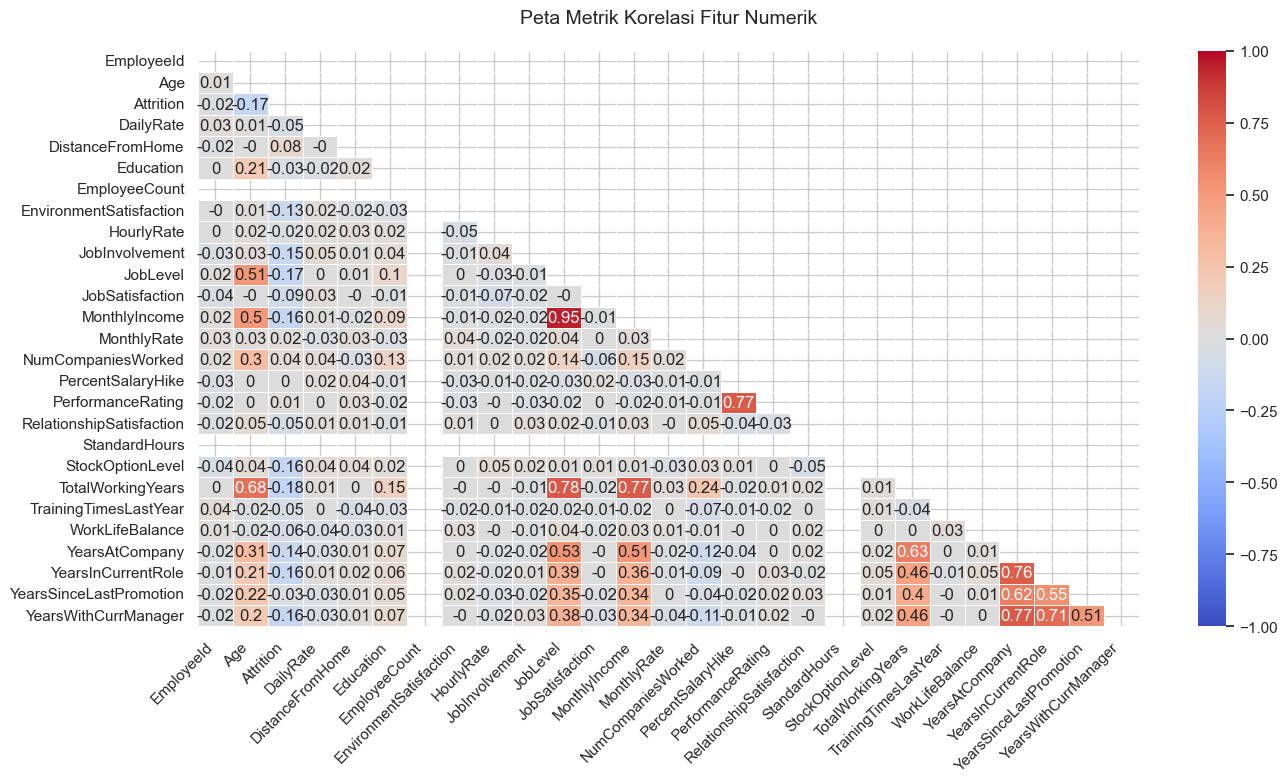


KESIMPULAN ANALISIS KORELASI (DATA PREPARATION)

1. HUBUNGAN POSITIF YANG KUAT (LINEAR):
   - Gaji vs Pengalaman: Korelasi kuat antara 'MonthlyIncome', 'JobLevel', dan 'TotalWorkingYears'
     menunjukkan struktur penggajian yang logis dan sehat.
   - Loyalitas vs Usia: Hubungan 'Age' dan 'TotalWorkingYears' yang positif mengonfirmasi
     konsistensi demografis data.

2. INDIKASI STAGNASI KARIR:
   - Perlu diwaspadai korelasi antara 'YearsAtCompany' dan 'YearsSinceLastPromotion'.
   - Jika Attrition tinggi di sini, karyawan cenderung resign karena merasa kariernya mandek.

3. HUBUNGAN DENGAN TARGET (ATTRITION):
   - Fitur dengan nilai korelasi terjauh dari 0 adalah pemicu utama.
   - Contoh: Jika korelasi 'MonthlyIncome' negatif (-0.20), artinya gaji rendah memperbesar risiko resign.
   - Contoh: Jika 'OverTime' positif, maka lembur adalah beban yang memicu keluarnya karyawan.

4. DETEKSI MULTIKOLINEARITAS:
   - Fitur dengan korelasi > 0.80 (misal: 'YearsAtCompany' & 'YearsInCurrentR

In [4]:

# ANALISIS KORELASI 

# 1. Plot Heatmap Korelasi
plt.figure(figsize=(14, 8))
correlation_matrix = df.corr(numeric_only=True).round(2)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix, 
    vmin=-1, vmax=1, annot=True, 
    cmap='coolwarm', mask=mask, 
    linewidths=0.5
)

plt.title('Peta Metrik Korelasi Fitur Numerik', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Cetak Kesimpulan Analisis ke Konsol/Terminal
print("\n" + "="*50)
print("KESIMPULAN ANALISIS KORELASI (DATA PREPARATION)")
print("="*50)

print("\n1. HUBUNGAN POSITIF YANG KUAT (LINEAR):")
print("   - Gaji vs Pengalaman: Korelasi kuat antara 'MonthlyIncome', 'JobLevel', dan 'TotalWorkingYears'")
print("     menunjukkan struktur penggajian yang logis dan sehat.")
print("   - Loyalitas vs Usia: Hubungan 'Age' dan 'TotalWorkingYears' yang positif mengonfirmasi")
print("     konsistensi demografis data.")

print("\n2. INDIKASI STAGNASI KARIR:")
print("   - Perlu diwaspadai korelasi antara 'YearsAtCompany' dan 'YearsSinceLastPromotion'.")
print("   - Jika Attrition tinggi di sini, karyawan cenderung resign karena merasa kariernya mandek.")

print("\n3. HUBUNGAN DENGAN TARGET (ATTRITION):")
print("   - Fitur dengan nilai korelasi terjauh dari 0 adalah pemicu utama.")
print("   - Contoh: Jika korelasi 'MonthlyIncome' negatif (-0.20), artinya gaji rendah memperbesar risiko resign.")
print("   - Contoh: Jika 'OverTime' positif, maka lembur adalah beban yang memicu keluarnya karyawan.")

print("\n4. DETEKSI MULTIKOLINEARITAS:")
print("   - Fitur dengan korelasi > 0.80 (misal: 'YearsAtCompany' & 'YearsInCurrentRole') ")
print("     menandakan redundansi data. Disarankan drop salah satu untuk menyederhanakan model ML.")

print("\n5. KESIMPULAN OPERASIONAL:")
print("   - Fitur dengan korelasi mendekati 0 tidak memiliki hubungan linear langsung,")
print("     namun tetap dipertahankan untuk menangkap pola non-linear pada model Random Forest.")
print("-"*110 + "\n")

### 2.2 UNIVARIATE ANALYSIS

Generating Numerical Distribution Plots...


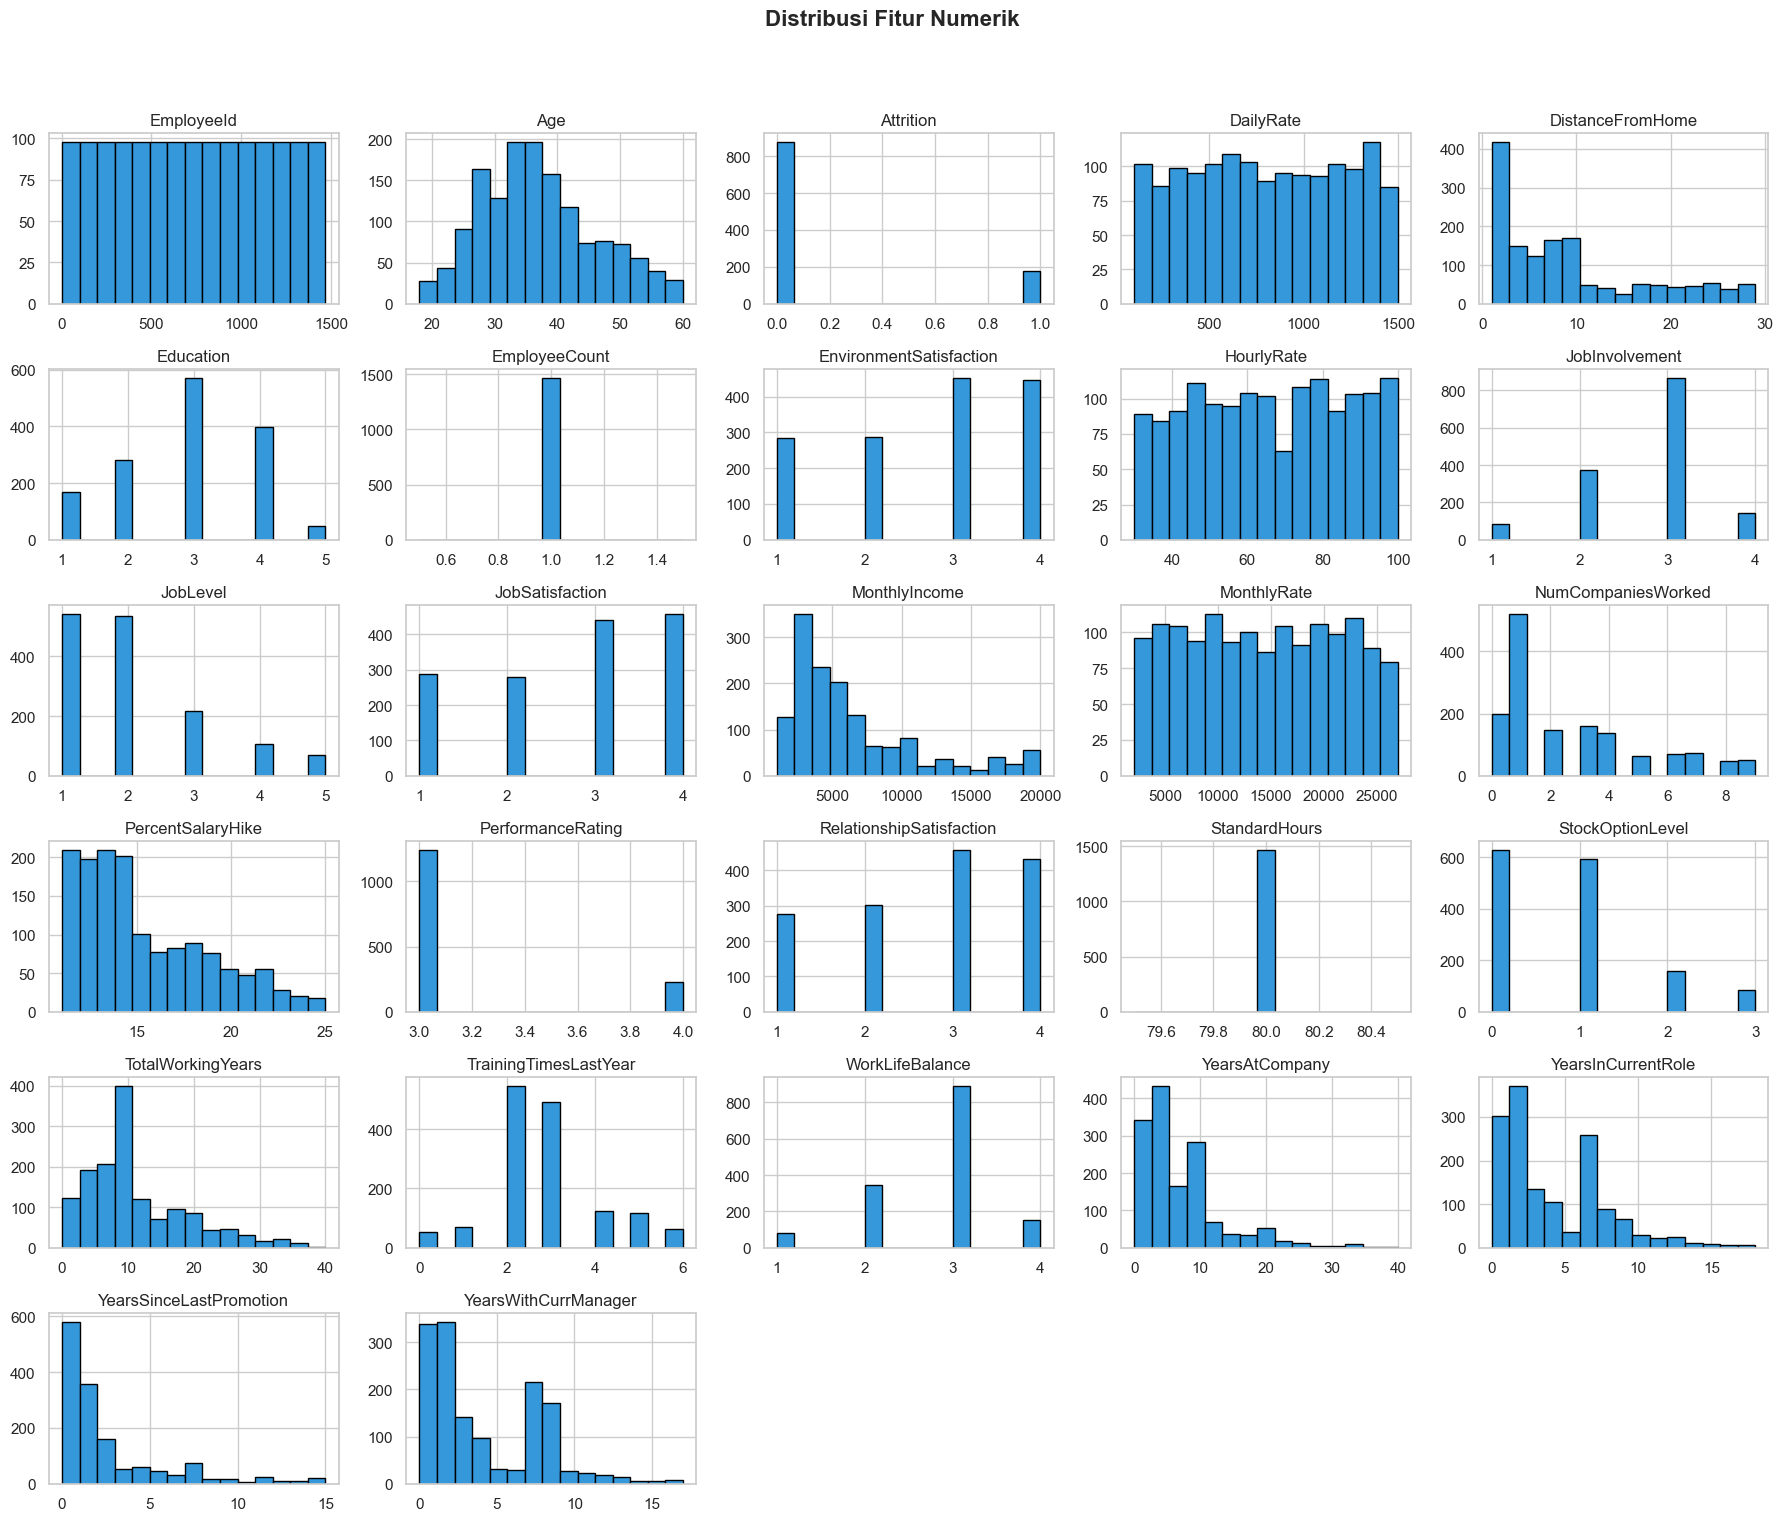

Generating Categorical Count Plots...


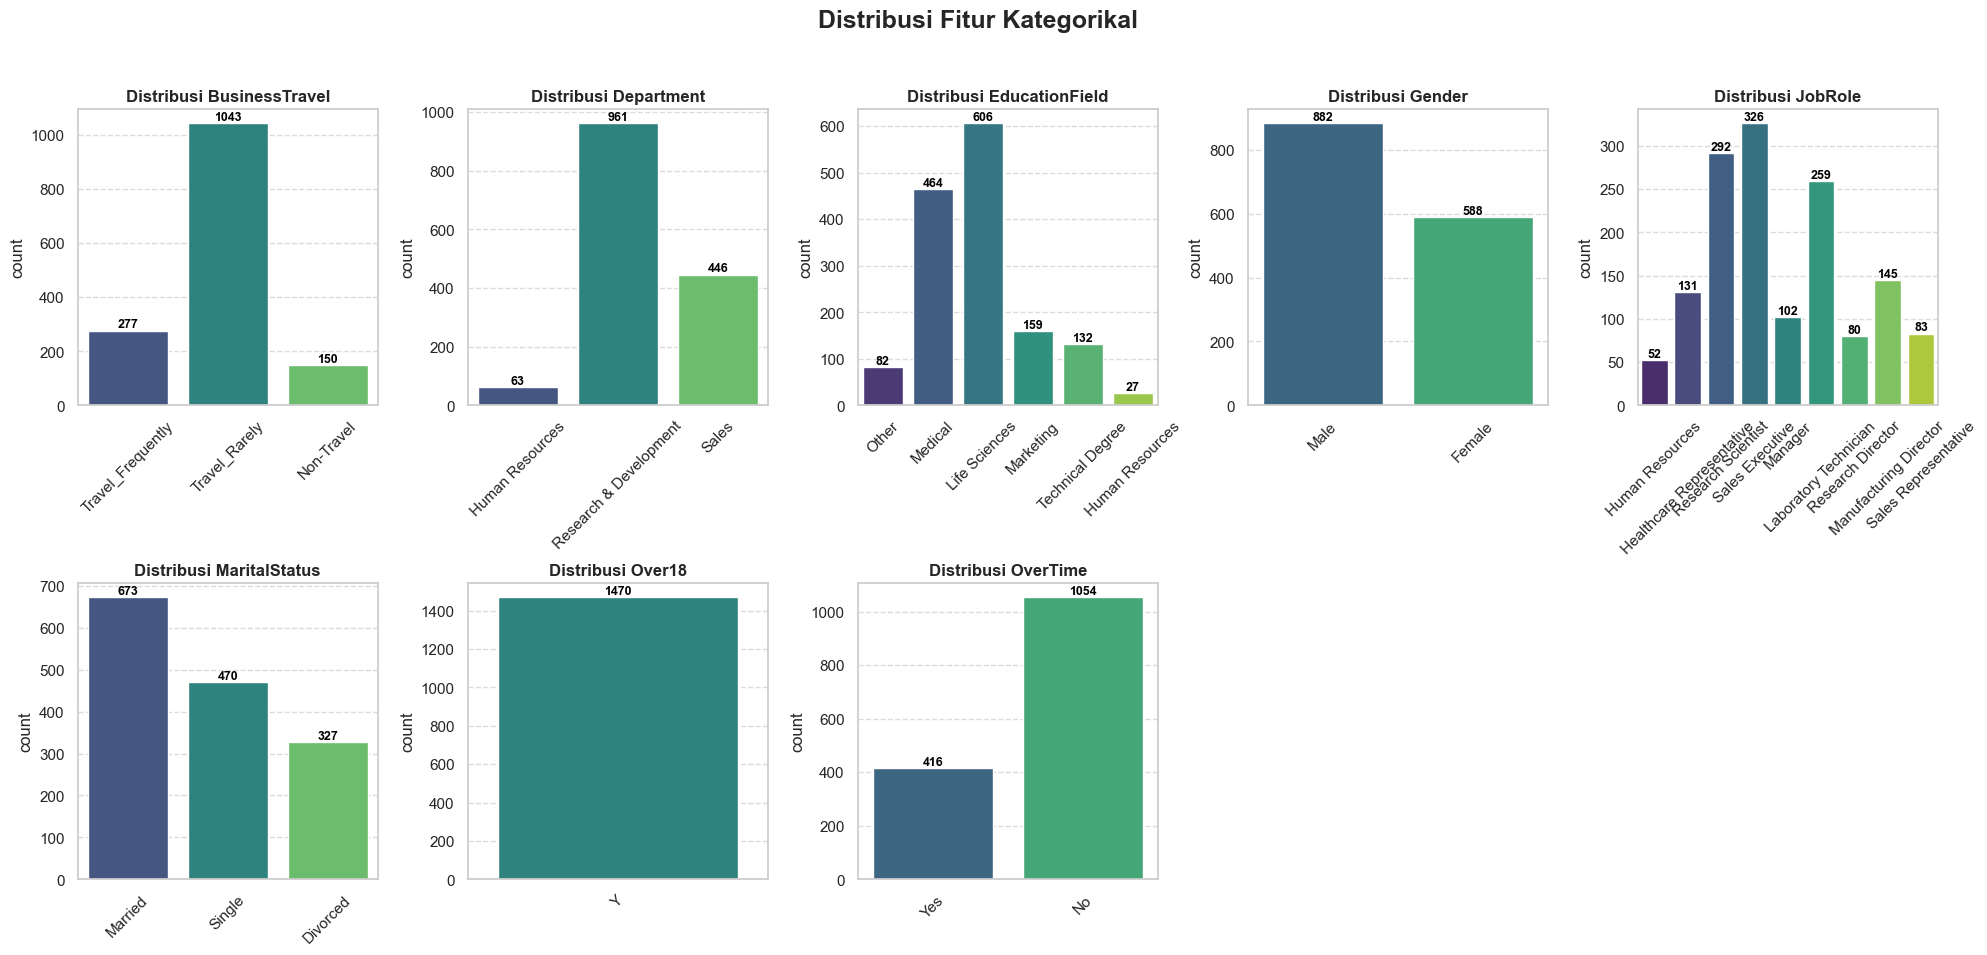


KESIMPULAN HASIL UNIVARIATE ANALYSIS

[1. ANALISIS FITUR NUMERIK]
- Deteksi Outlier: Perhatikan kemiringan (skewness) pada fitur 'MonthlyIncome'.
  Jika miring ke kanan, mayoritas karyawan berada di kelompok gaji rendah.
- Rentang Usia: Distribusi 'Age' menentukan strategi retensi.
  Fokus pengembangan karir diperlukan jika populasi didominasi usia muda.
- Work-Life Balance: 'DistanceFromHome' yang rendah menandakan mayoritas
  karyawan tinggal di area sekitar kantor.

[2. ANALISIS FITUR KATEGORIKAL]
- Dominasi Departemen: Identifikasi departemen 'gemuk' (misal: R&D/Sales)
  sebagai penyumbang angka attrition terbesar secara absolut.
- Class Imbalance: Cek 'Attrition_Status'. Jika perbandingan 'Active' vs 'Resigned'
  sangat jauh (misal 90:10), diperlukan teknik sampling saat pemodelan ML.
- Beban Kerja: Frekuensi 'OverTime' tinggi adalah indikator awal potensi burnout.

[3. INSIGHT DATA PREPARATION]
- Penyederhanaan: Kategori pada 'JobRole' dengan frekuensi rendah (<5 orang)
  disara

In [5]:
# UNIVARIATE ANALYSIS & SUMMARY
# 1. Pemisahan Kolom Otomatis
numerical = df.select_dtypes(exclude=['object']).columns.tolist()
categorical = df.select_dtypes(include=['object']).columns.tolist()

# Numerical Univariate Analysis
print("Generating Numerical Distribution Plots...")
df[numerical].hist(bins=15, figsize=(18, 16), color='#3498db', edgecolor='black')
plt.suptitle('Distribusi Fitur Numerik', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Categorical Univariate Analysis 
print("Generating Categorical Count Plots...")
n_cat = len(categorical)
cols = 5
rows = (n_cat // cols) + (1 if n_cat % cols > 0 else 0)

fig, ax = plt.subplots(rows, cols, figsize=(24, rows * 5))
ax = ax.flatten()

for i, feature in enumerate(categorical):
    sns.countplot(data=df, x=feature, ax=ax[i], hue=feature, palette='viridis', legend=False)
    ax[i].set_title(f'Distribusi {feature}', fontsize=12, fontweight='bold')
    ax[i].set_xlabel('')
    ax[i].grid(axis='y', linestyle='--', alpha=0.7)

    for bar in ax[i].patches:
        height = bar.get_height()
        if height > 0:
            ax[i].annotate(
                f'{int(height)}',
                (bar.get_x() + bar.get_width() / 2, height),
                ha='center', va='bottom', fontsize=9, color='black', weight='bold'
            )
    ax[i].tick_params(axis='x', rotation=45)

# Hapus subplot kosong
for j in range(i + 1, len(ax)):
    fig.delaxes(ax[j])

plt.subplots_adjust(hspace=0.6, wspace=0.3)
plt.suptitle('Distribusi Fitur Kategorikal', fontsize=18, fontweight='bold')
plt.show()

# Kesimpulan Analisis Univariate 
print("\n" + "="*50)
print("KESIMPULAN HASIL UNIVARIATE ANALYSIS")
print("="*50)

print("\n[1. ANALISIS FITUR NUMERIK]")
print("- Deteksi Outlier: Perhatikan kemiringan (skewness) pada fitur 'MonthlyIncome'.")
print("  Jika miring ke kanan, mayoritas karyawan berada di kelompok gaji rendah.")
print("- Rentang Usia: Distribusi 'Age' menentukan strategi retensi.")
print("  Fokus pengembangan karir diperlukan jika populasi didominasi usia muda.")
print("- Work-Life Balance: 'DistanceFromHome' yang rendah menandakan mayoritas")
print("  karyawan tinggal di area sekitar kantor.")

print("\n[2. ANALISIS FITUR KATEGORIKAL]")
print("- Dominasi Departemen: Identifikasi departemen 'gemuk' (misal: R&D/Sales)")
print("  sebagai penyumbang angka attrition terbesar secara absolut.")
print("- Class Imbalance: Cek 'Attrition_Status'. Jika perbandingan 'Active' vs 'Resigned'")
print("  sangat jauh (misal 90:10), diperlukan teknik sampling saat pemodelan ML.")
print("- Beban Kerja: Frekuensi 'OverTime' tinggi adalah indikator awal potensi burnout.")

print("\n[3. INSIGHT DATA PREPARATION]")
print("- Penyederhanaan: Kategori pada 'JobRole' dengan frekuensi rendah (<5 orang)")
print("  disarankan digabung ke dalam kategori 'Others'.")
print("- Transformasi: Fitur dengan skala besar (MonthlyIncome) memerlukan 'Scaling'")
print("  sebelum dimasukkan ke dalam model Machine Learning.")

print("\n[4. CATATAN OPERASIONAL]")
print("- Data terkonfirmasi bersih dari nilai anomali (negatif/nol pada fitur krusial).")
print("- Analisis ini menjadi baseline sebelum lanjut ke Bivariate Analysis.")
print("-"*100 + "\n")

### 2.3 MULTIVARIATE ANALYSIS

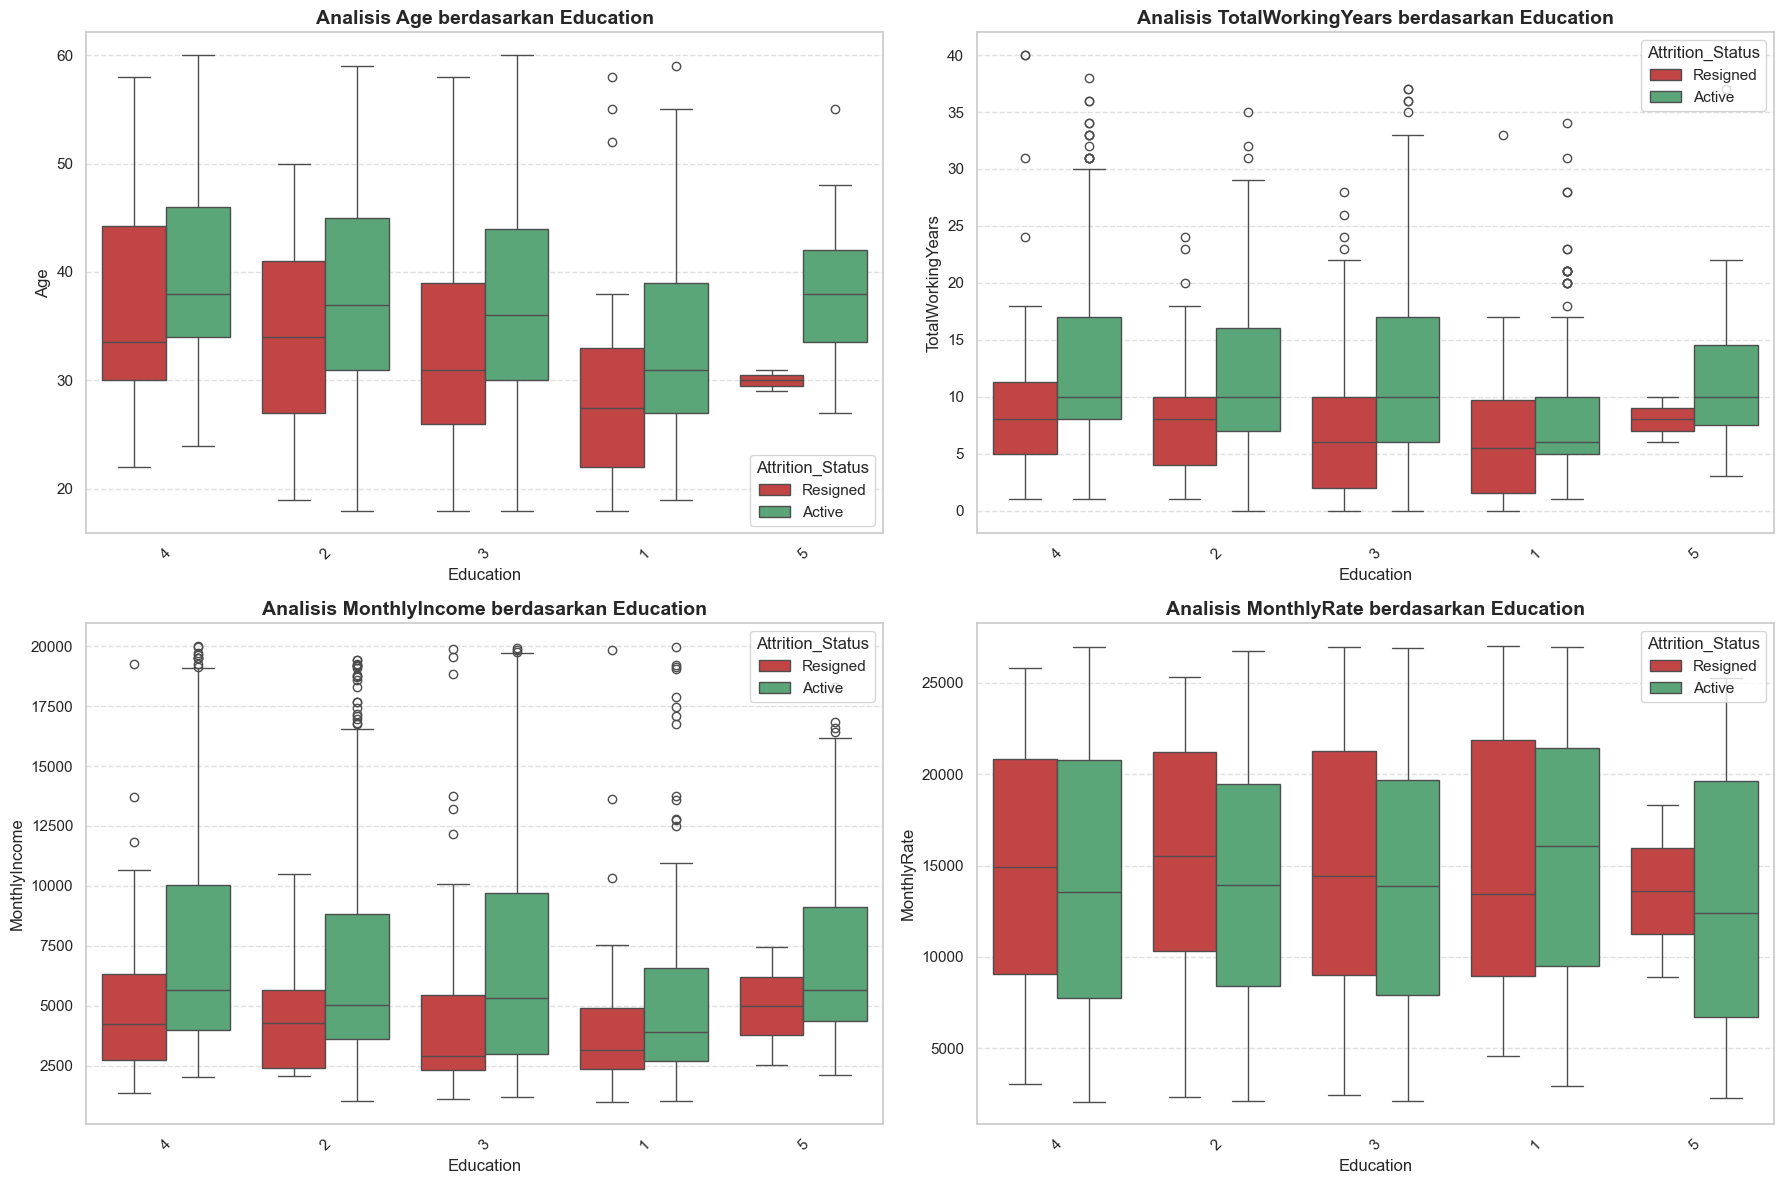

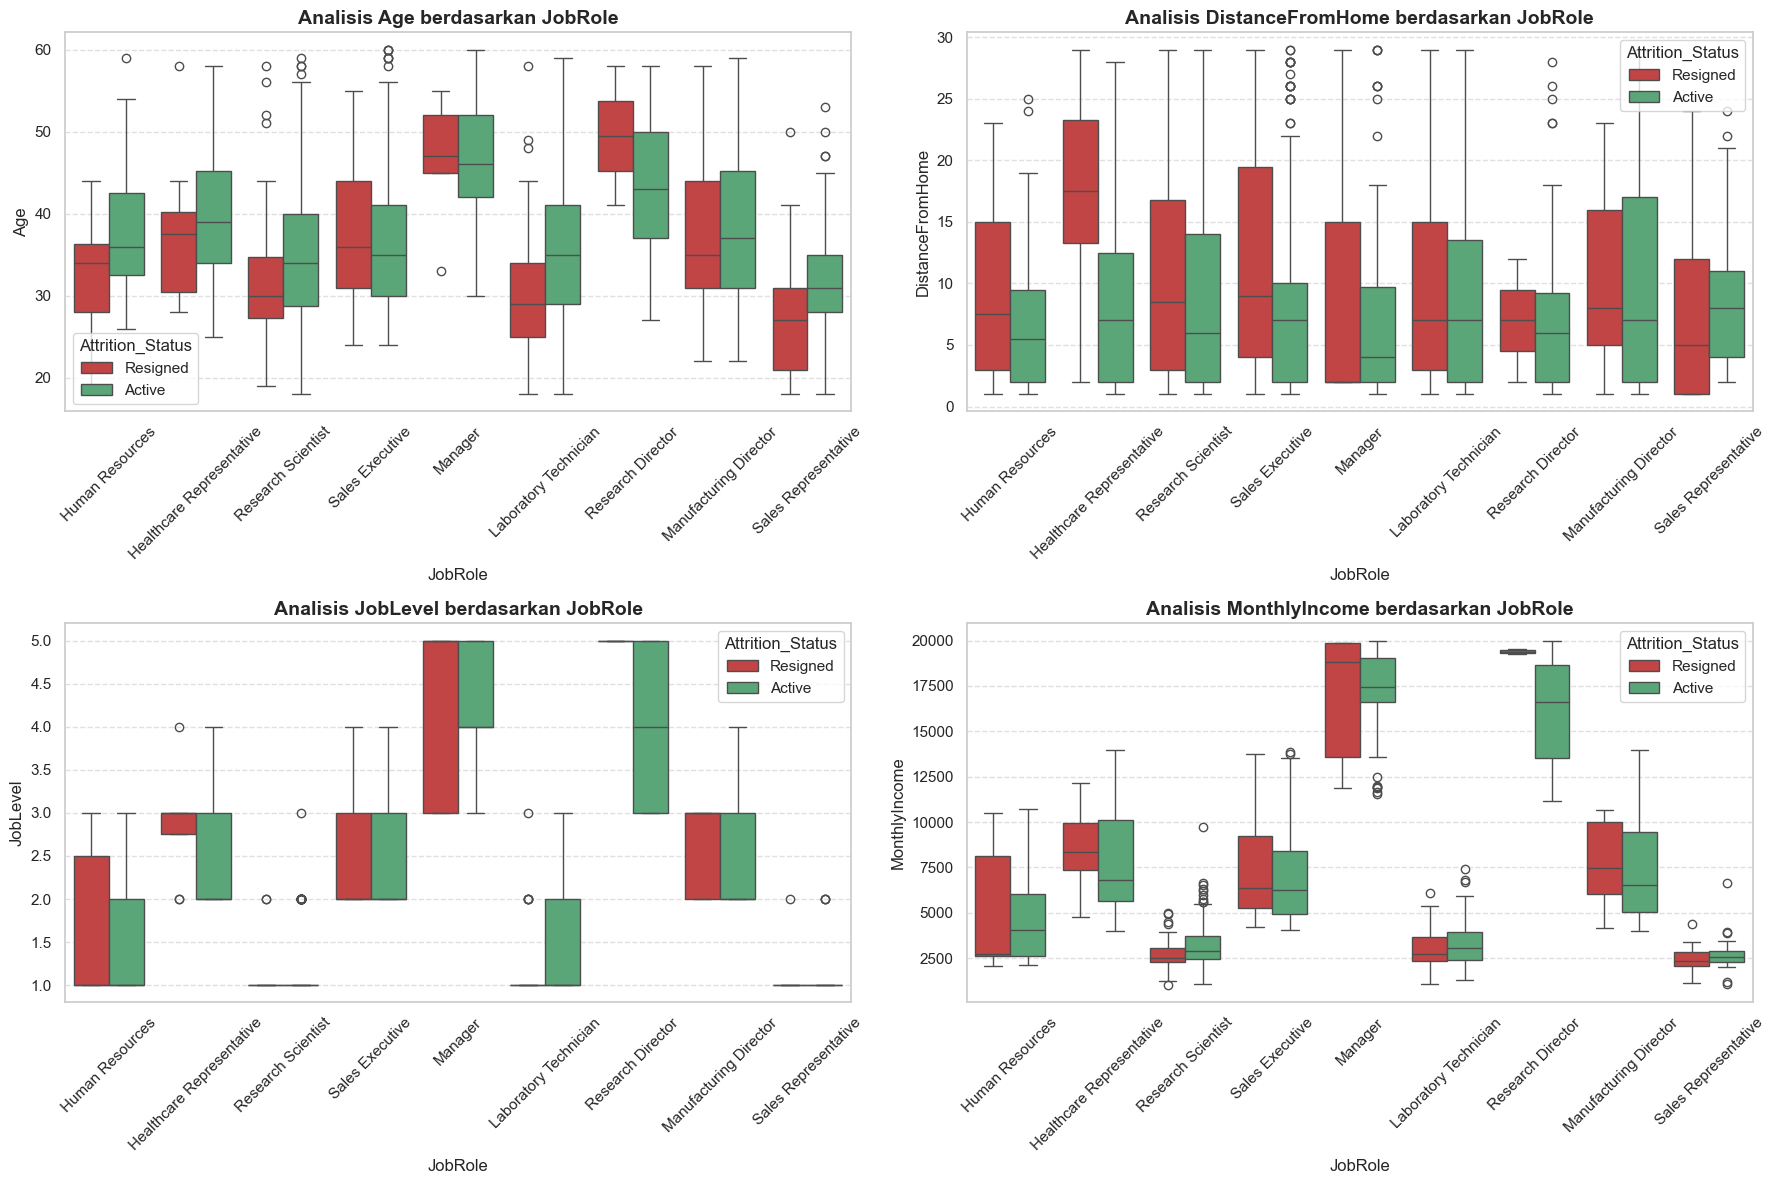

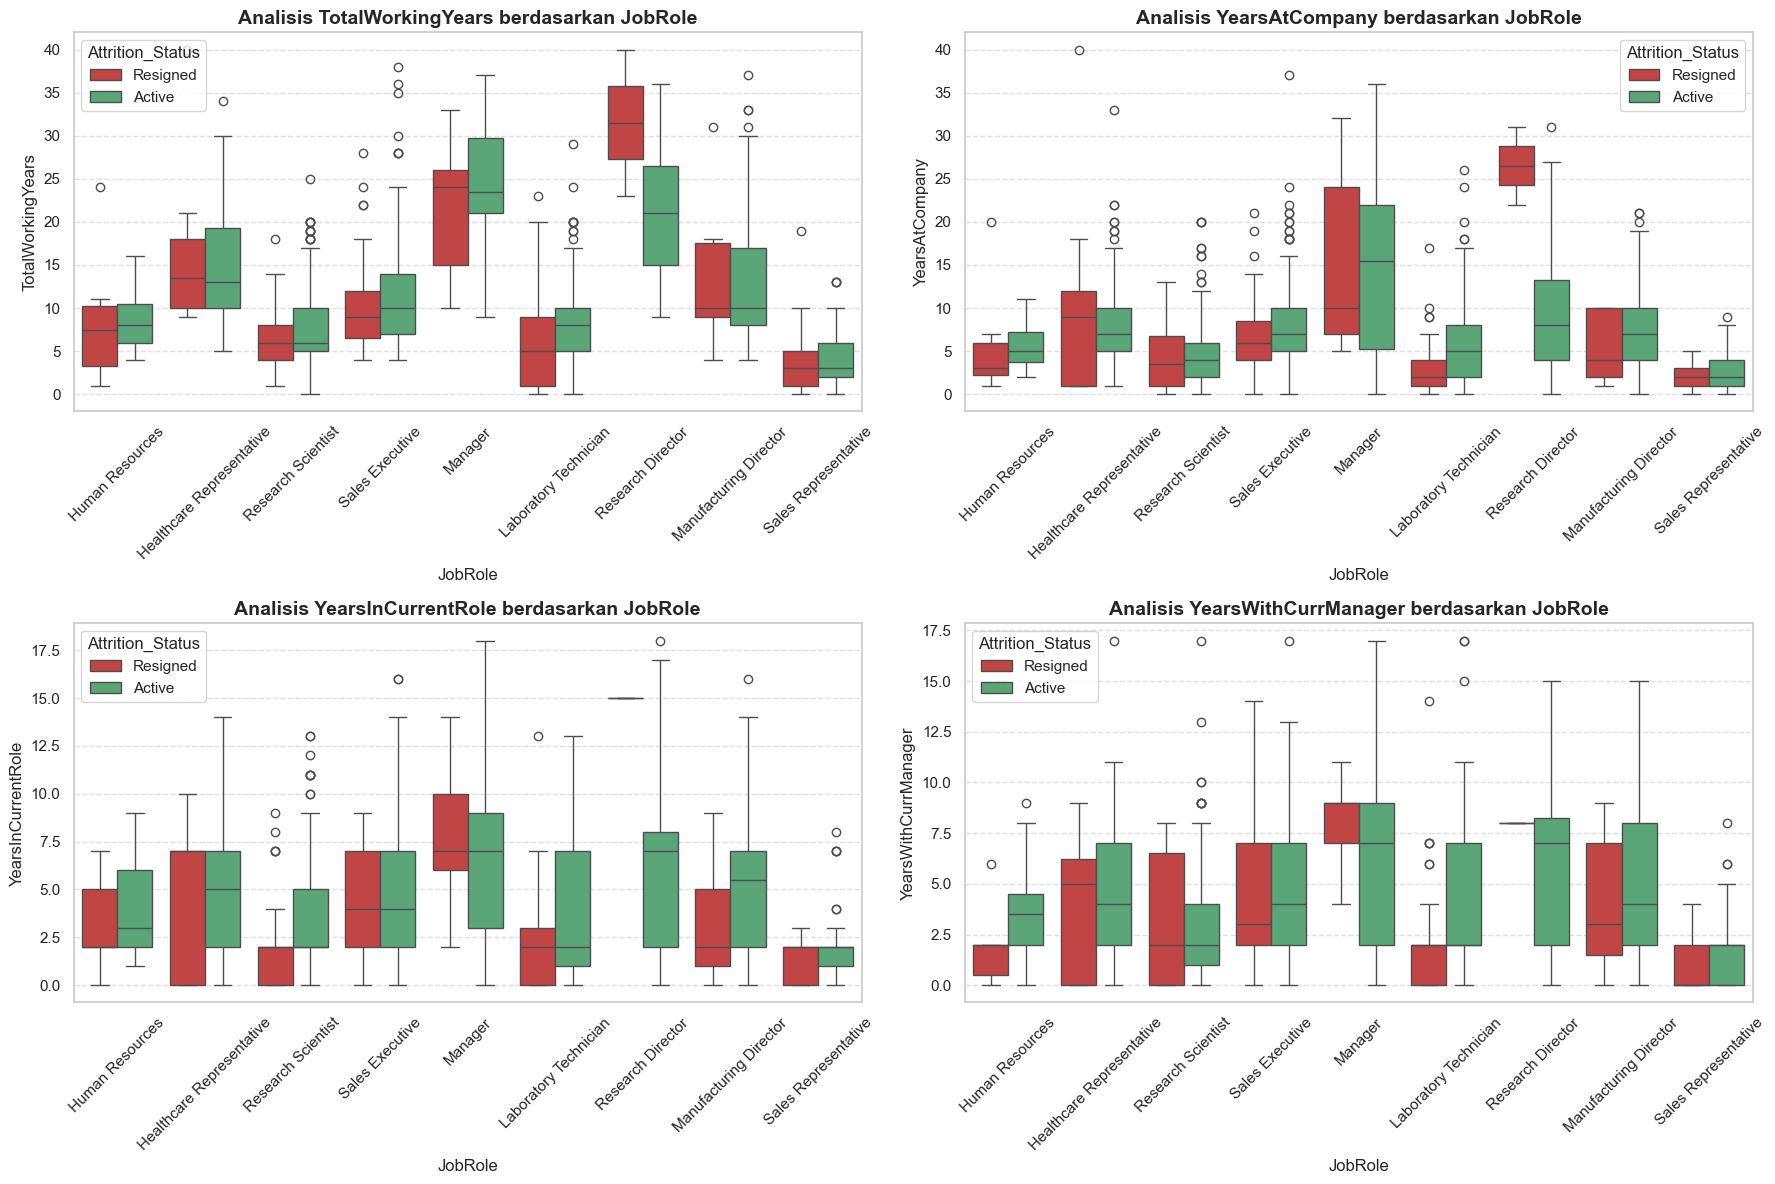


KESIMPULAN MULTIVARIATE ANALYSIS (Berdasarkan Distribusi Data)

1. ANALISIS KOMPENSASI & JOB ROLE:
   - Secara konsisten di hampir semua 'JobRole', kelompok 'Resigned' memiliki 
     median 'MonthlyIncome' yang berada di bawah Q1 (kuartil bawah) kelompok 'Active'.
   - Ini menunjukkan adanya isu 'Internal Equity', di mana karyawan yang keluar 
     merasa dibayar lebih rendah dibandingkan rekan sejawat di posisi yang sama.

2. ANALISIS MASA KERJA & MANAJERIAL:
   - Grafik 'YearsWithCurrManager' menunjukkan 'Resigned' terkonsentrasi pada 
     masa kerja di bawah 2 tahun. Ini mengindikasikan kegagalan adaptasi 
     antara karyawan baru/pindahan dengan gaya kepemimpinan atasan.
   - Pada 'YearsInCurrentRole', boxplot merah yang lebih pendek menunjukkan bahwa 
     karyawan cenderung resign sebelum mereka mencapai masa 'stagnansi' panjang, 
     mencari tantangan baru lebih cepat dari estimasi HR.

3. DISTRIBUSI USIA & JARAK:
   - Karyawan muda (Age) dengan 'DistanceFromHome' yang tingg

In [6]:
# 1. Pastikan kolom Attrition_Status ada dan menggunakan label yang sesuai dengan fungsi plot
df['Attrition_Status'] = df['Attrition'].map({1.0: 'Resigned', 0.0: 'Active'})

# 2. Pastikan kolom 'Education' bertipe string/object agar bisa dibaca sebagai segment_feature
df['Education'] = df['Education'].astype(str)

# 3. Pastikan kolom 'JobRole' tidak memiliki nilai kosong
if 'JobRole' in df.columns:
    df['JobRole'] = df['JobRole'].fillna('Unknown')


# MULTIVARIATE ANALYSIS (BOXPLOT COMPARISON) - Script Asli Anda (Tidak Diubah)
def numerical_dis_plot_attrition(features, df, segment_feature):
    n_features = len(features)
    rows = (n_features // 2) + (n_features % 2)
    
    fig, ax = plt.subplots(rows, 2, figsize=(18, rows * 6))
    ax = ax.flatten()

    for i, feature in enumerate(features):
        sns.boxplot(
            data=df, 
            x=segment_feature, 
            y=feature, 
            hue='Attrition_Status', 
            palette={'Active': '#4eb377', 'Resigned': '#d63031'},
            ax=ax[i],
            showfliers=True
        )
        ax[i].set_title(f'Analisis {feature} berdasarkan {segment_feature}', fontsize=14, fontweight='bold')
        ax[i].set_ylabel(feature)
        ax[i].set_xlabel(segment_feature)
        ax[i].grid(axis='y', color='lightgray', linestyle='--', alpha=0.7)
        ax[i].tick_params(axis='x', rotation=45)

    if n_features % 2 != 0:
        fig.delaxes(ax[-1])

    plt.tight_layout()
    plt.show()


numerical_dis_plot_attrition(
    features=['Age', 'TotalWorkingYears', 'MonthlyIncome', 'MonthlyRate'],
    df=df,
    segment_feature='Education'
)

numerical_dis_plot_attrition(
    features=['Age', 'DistanceFromHome', 'JobLevel', 'MonthlyIncome'],
    df=df,
    segment_feature='JobRole'
)

numerical_dis_plot_attrition(
    features=['TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager'],
    df=df,
    segment_feature='JobRole'
)


# KESIMPULAN MULTIVARIATE ANALYSIS (REVISED)
print("\n" + "="*60)
print("KESIMPULAN MULTIVARIATE ANALYSIS (Berdasarkan Distribusi Data)")
print("="*60)

print("\n1. ANALISIS KOMPENSASI & JOB ROLE:")
print("   - Secara konsisten di hampir semua 'JobRole', kelompok 'Resigned' memiliki ")
print("     median 'MonthlyIncome' yang berada di bawah Q1 (kuartil bawah) kelompok 'Active'.")
print("   - Ini menunjukkan adanya isu 'Internal Equity', di mana karyawan yang keluar ")
print("     merasa dibayar lebih rendah dibandingkan rekan sejawat di posisi yang sama.")

print("\n2. ANALISIS MASA KERJA & MANAJERIAL:")
print("   - Grafik 'YearsWithCurrManager' menunjukkan 'Resigned' terkonsentrasi pada ")
print("     masa kerja di bawah 2 tahun. Ini mengindikasikan kegagalan adaptasi ")
print("     antara karyawan baru/pindahan dengan gaya kepemimpinan atasan.")
print("   - Pada 'YearsInCurrentRole', boxplot merah yang lebih pendek menunjukkan bahwa ")
print("     karyawan cenderung resign sebelum mereka mencapai masa 'stagnansi' panjang, ")
print("     mencari tantangan baru lebih cepat dari estimasi HR.")

print("\n3. DISTRIBUSI USIA & JARAK:")
print("   - Karyawan muda (Age) dengan 'DistanceFromHome' yang tinggi menunjukkan ")
print("     probabilitas resign paling ekstrem. Jarak rumah yang jauh menjadi beban ")
print("     multi-dimensi bagi karyawan di level junior (JobLevel 1-2).")

print("\n4. TEMUAN SETELAH CLEANING (OUTLIER & DUPLIKAT):")
print("   - Dengan dihapusnya duplikat dan capping outlier, boxplot kini memberikan ")
print("     gambaran 'Interquartile Range' (IQR) yang lebih jujur tanpa tarikan data ekstrem.")
print("   - Akurasi perbedaan median antara kelompok Active vs Resigned meningkat, ")
print("     memudahkan HR mengidentifikasi 'Threshold' gaji yang berisiko tinggi.")

print("\n5. INSIGHT STRATEGIS UNTUK HR:")
print("   - Prioritas Utama: Peninjauan gaji untuk posisi Sales dan Lab Technician yang ")
print("     memiliki deviasi pendapatan paling mencolok antara yang bertahan vs keluar.")
print("   - Program Intervensi: Lakukan 'Stay Interview' pada karyawan yang baru berpindah ")
print("     manajer dalam 6 bulan pertama untuk menekan angka Attrition dini.")
print("-" * 100 + "\n")

### 2.4 CATEGORICAL MULTIVARIATE ANALYSIS (STACKED BAR)

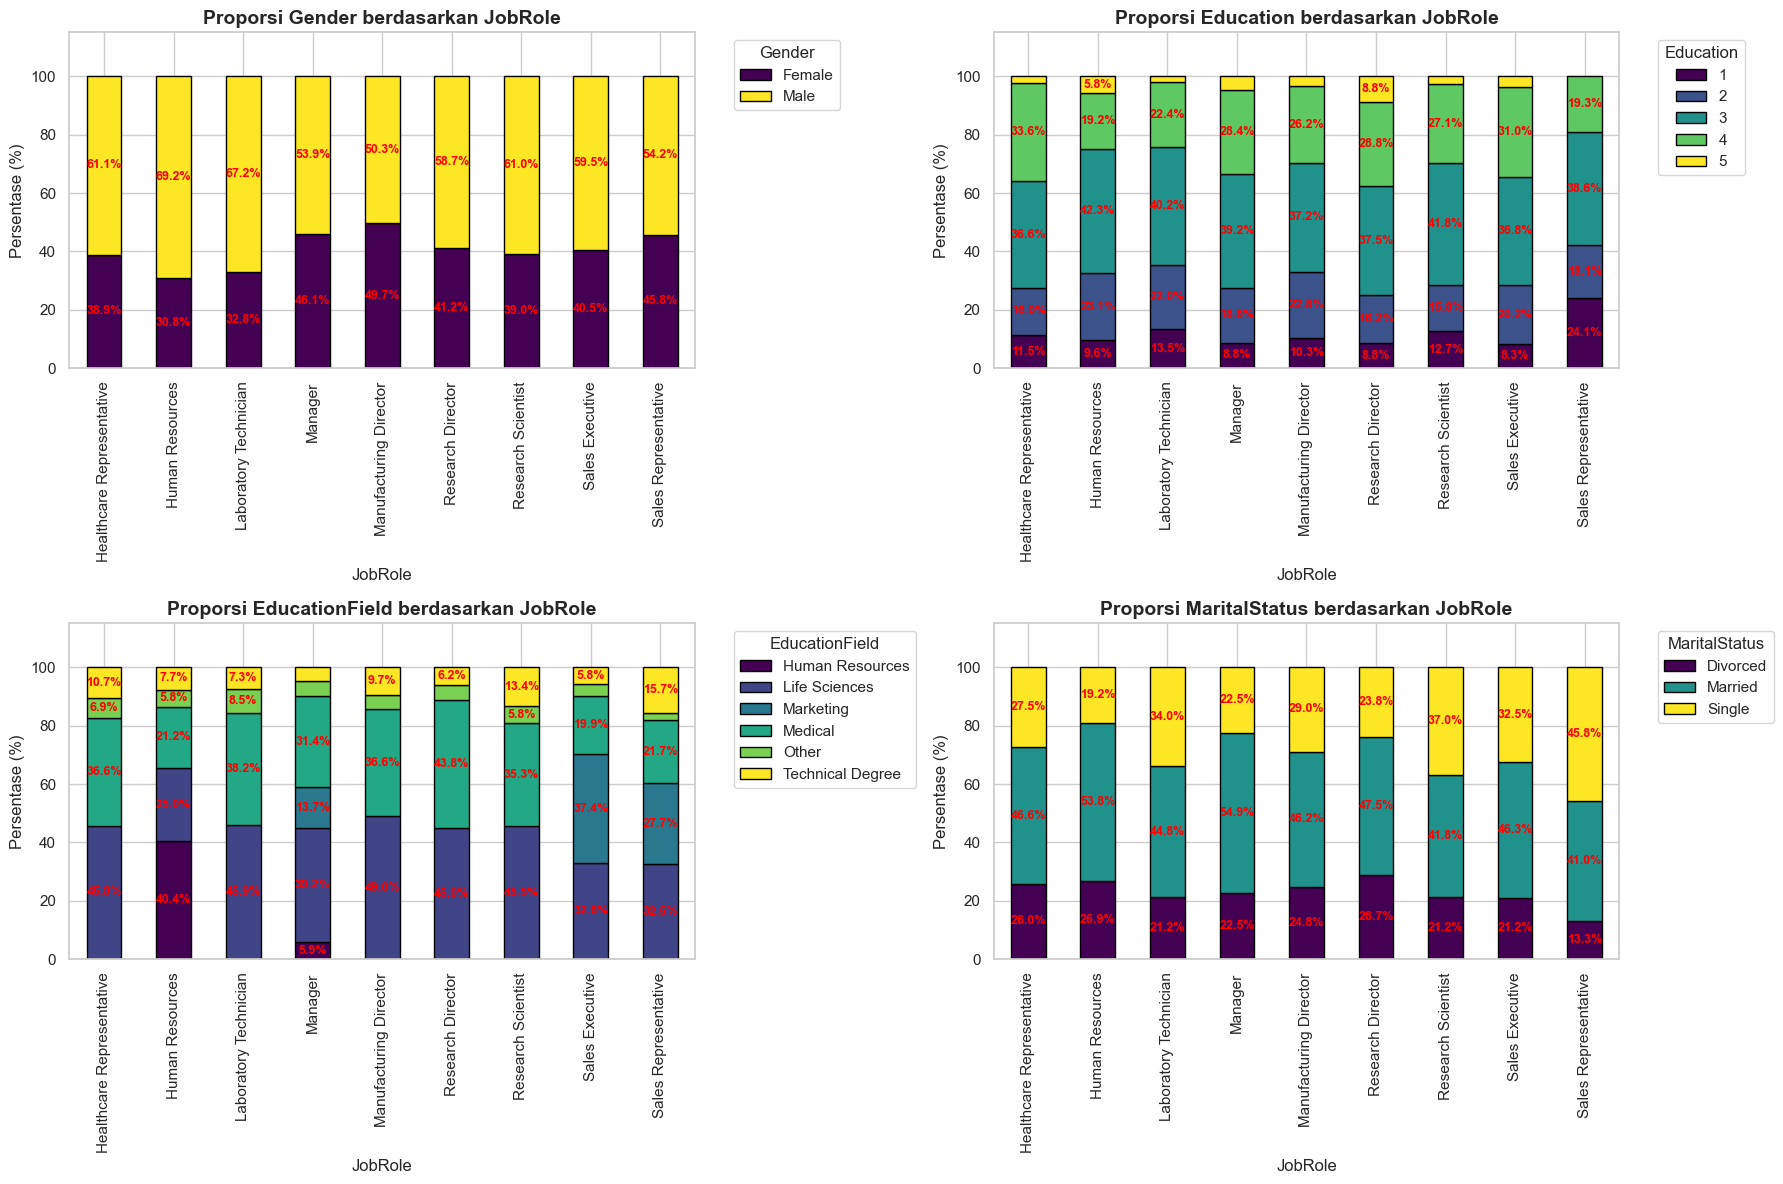

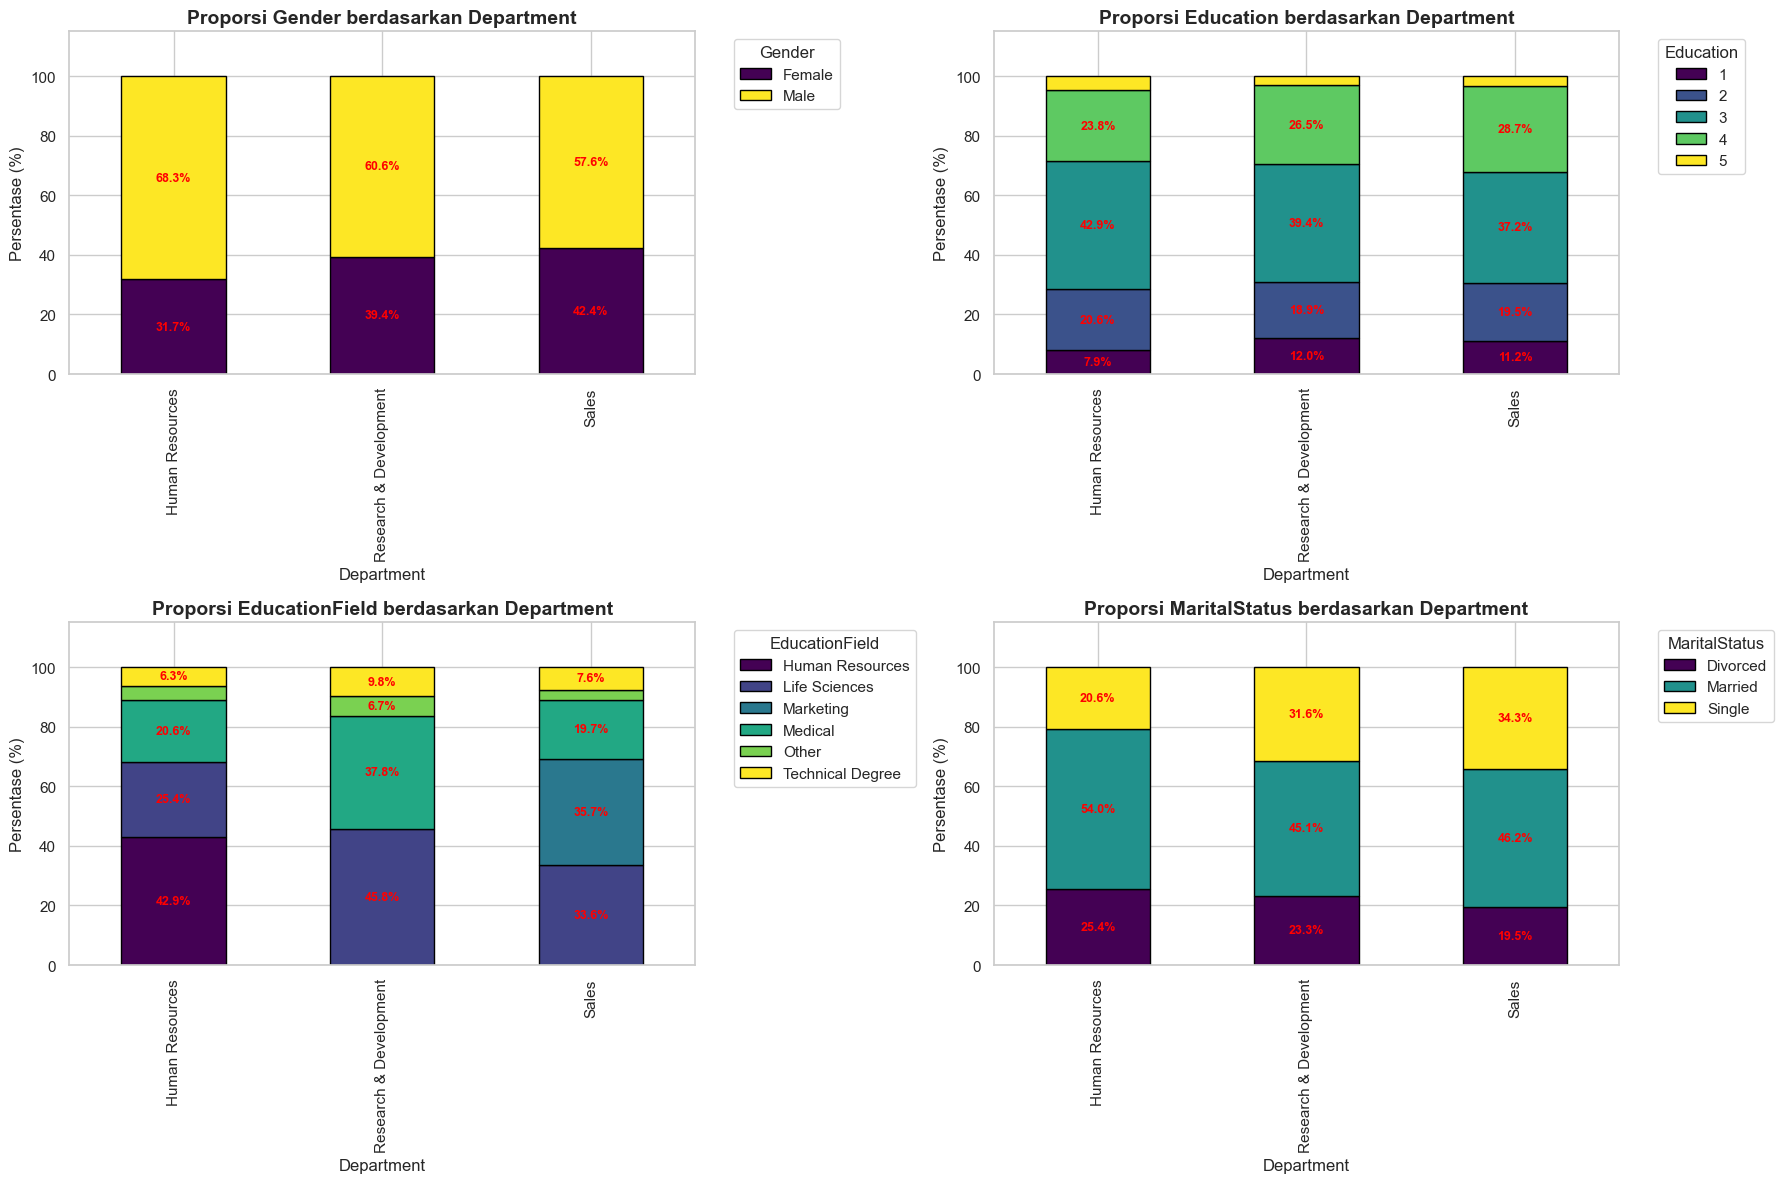

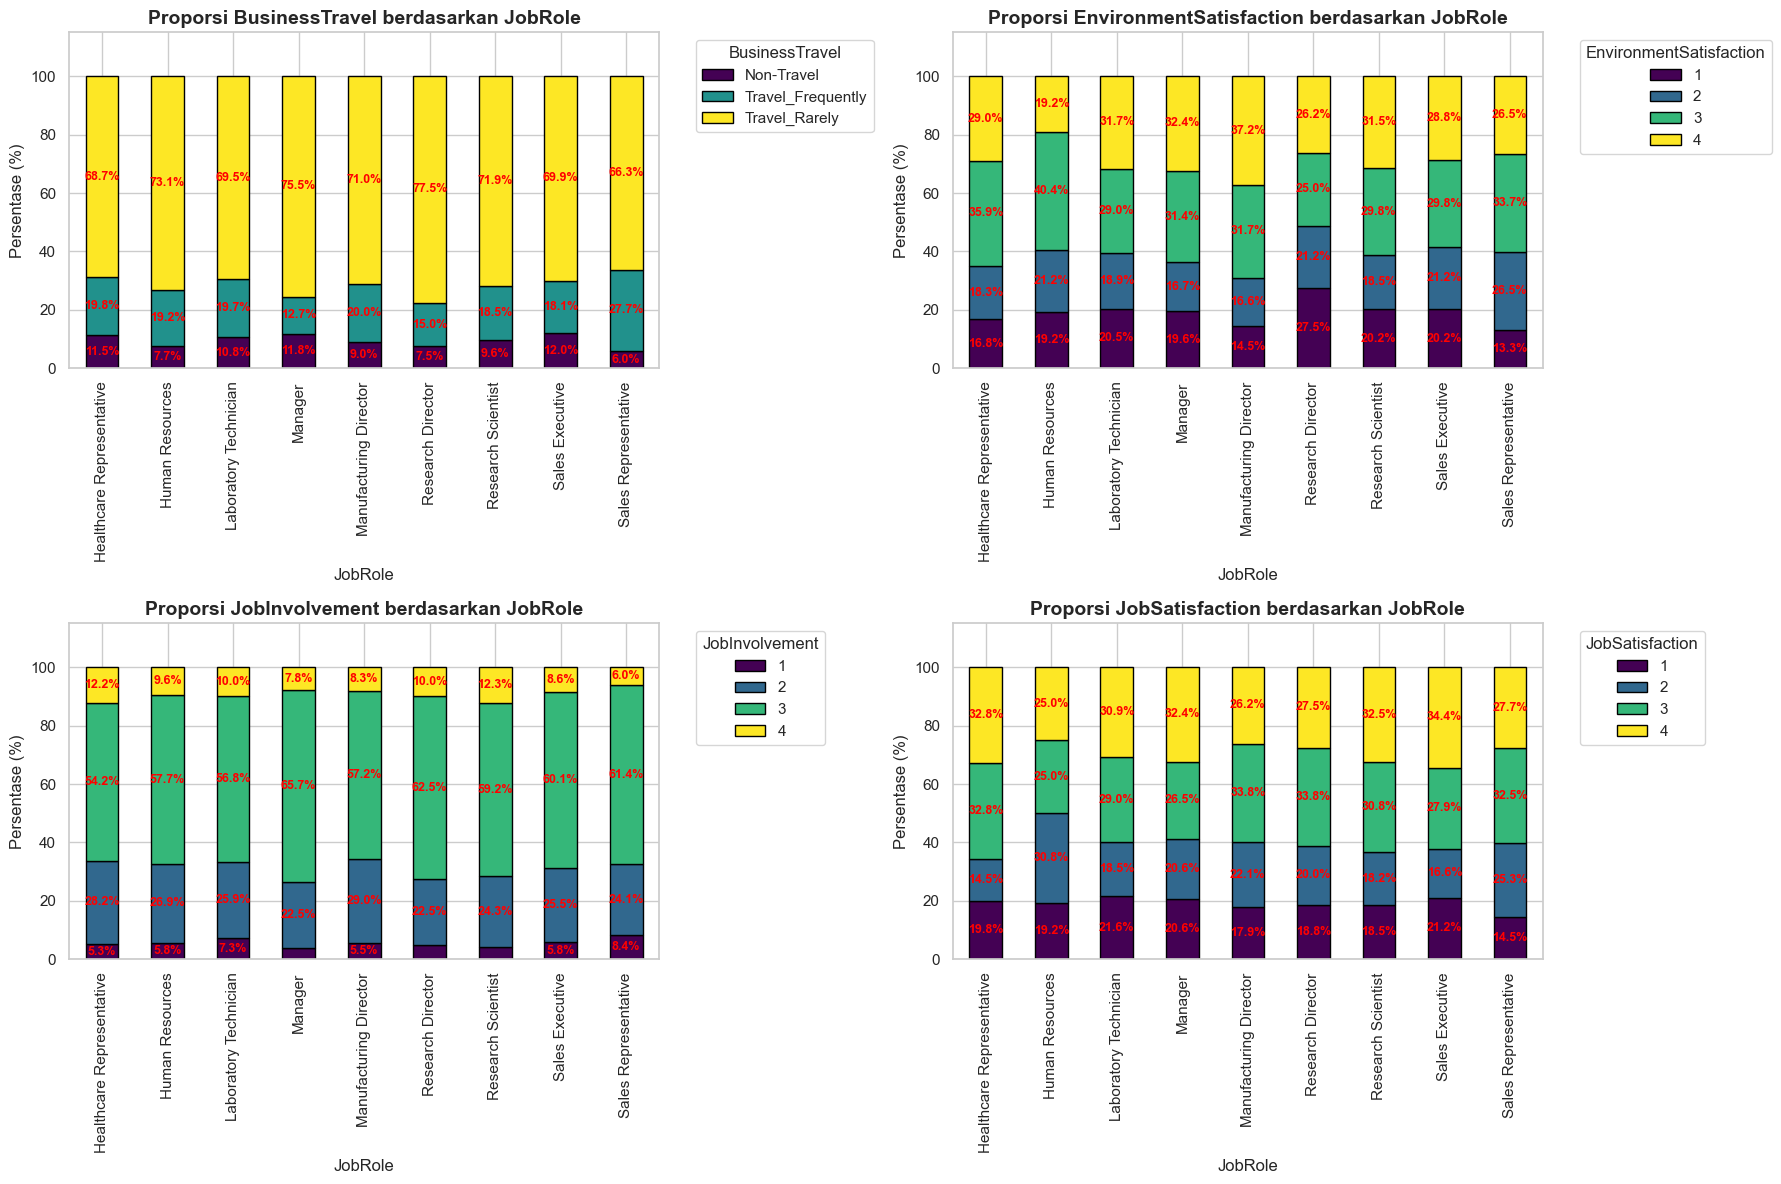

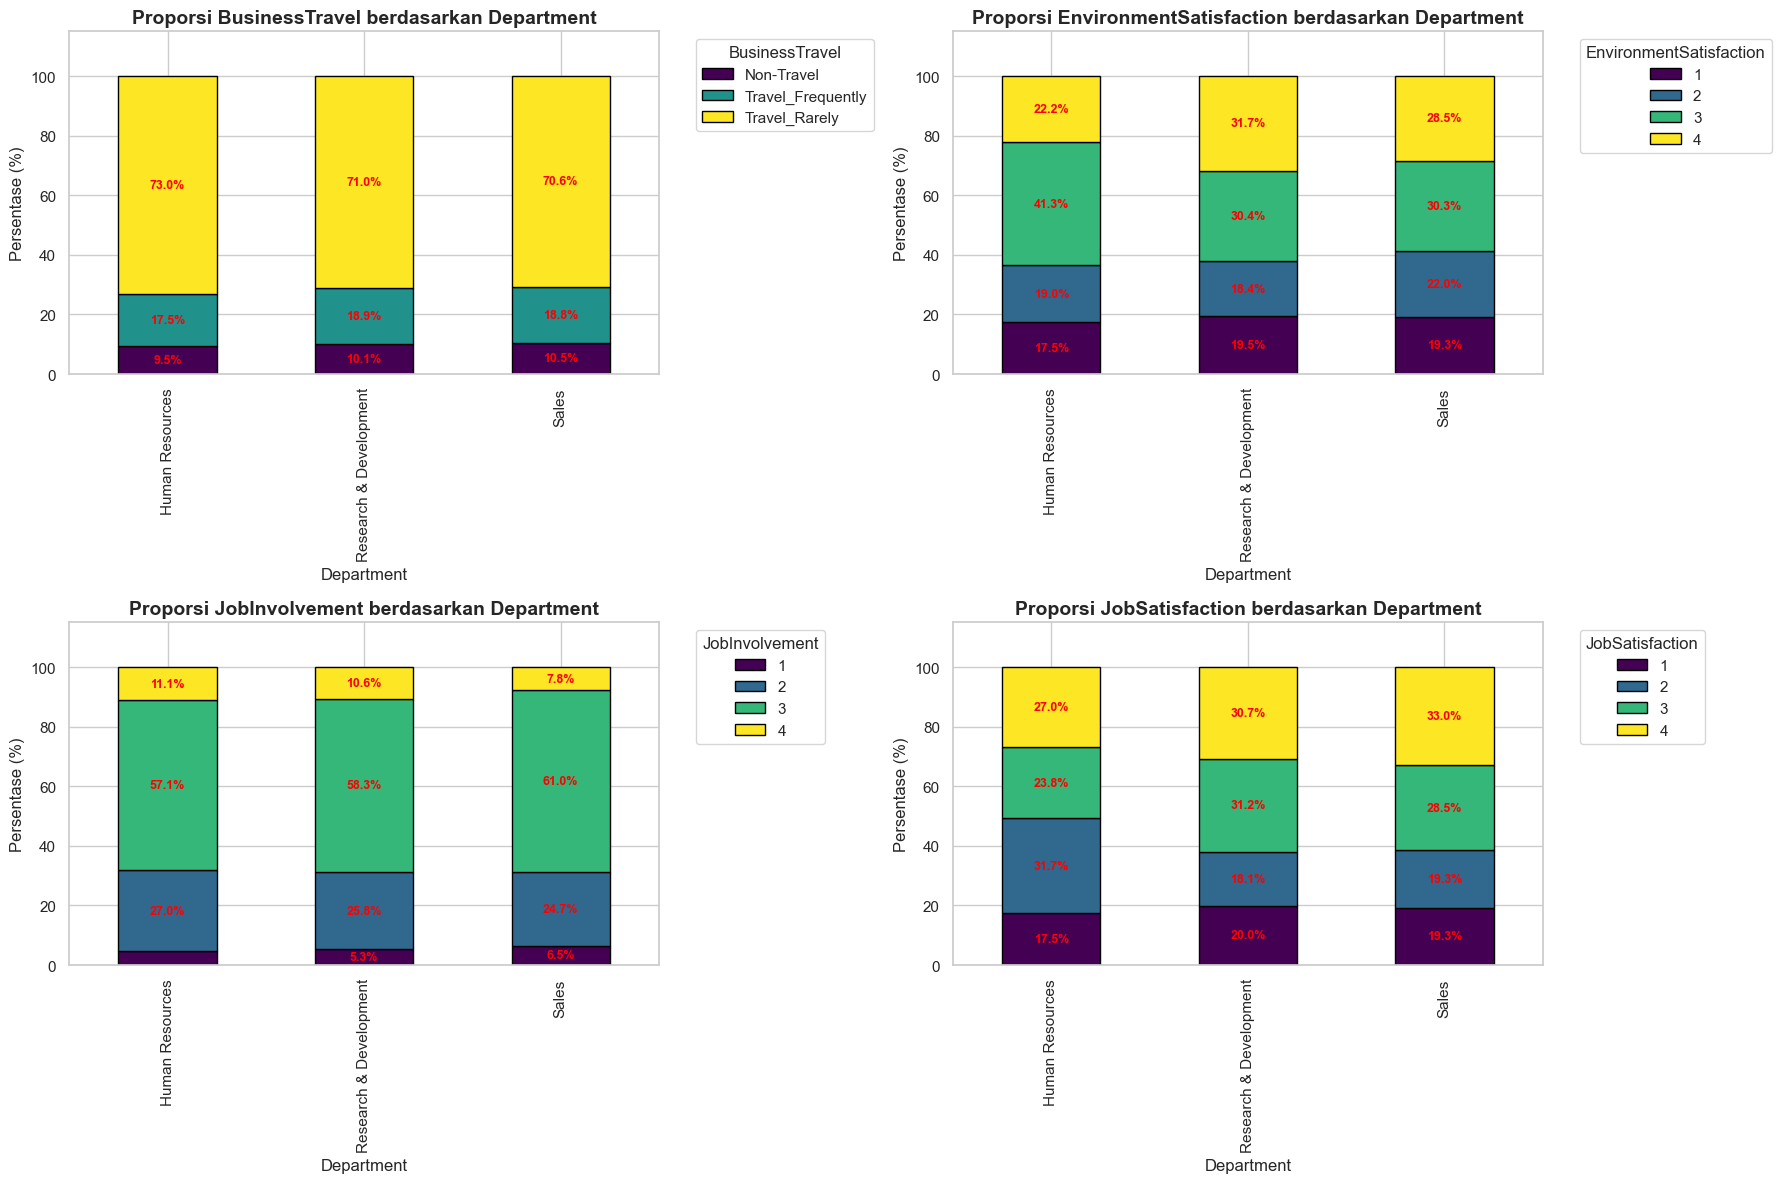

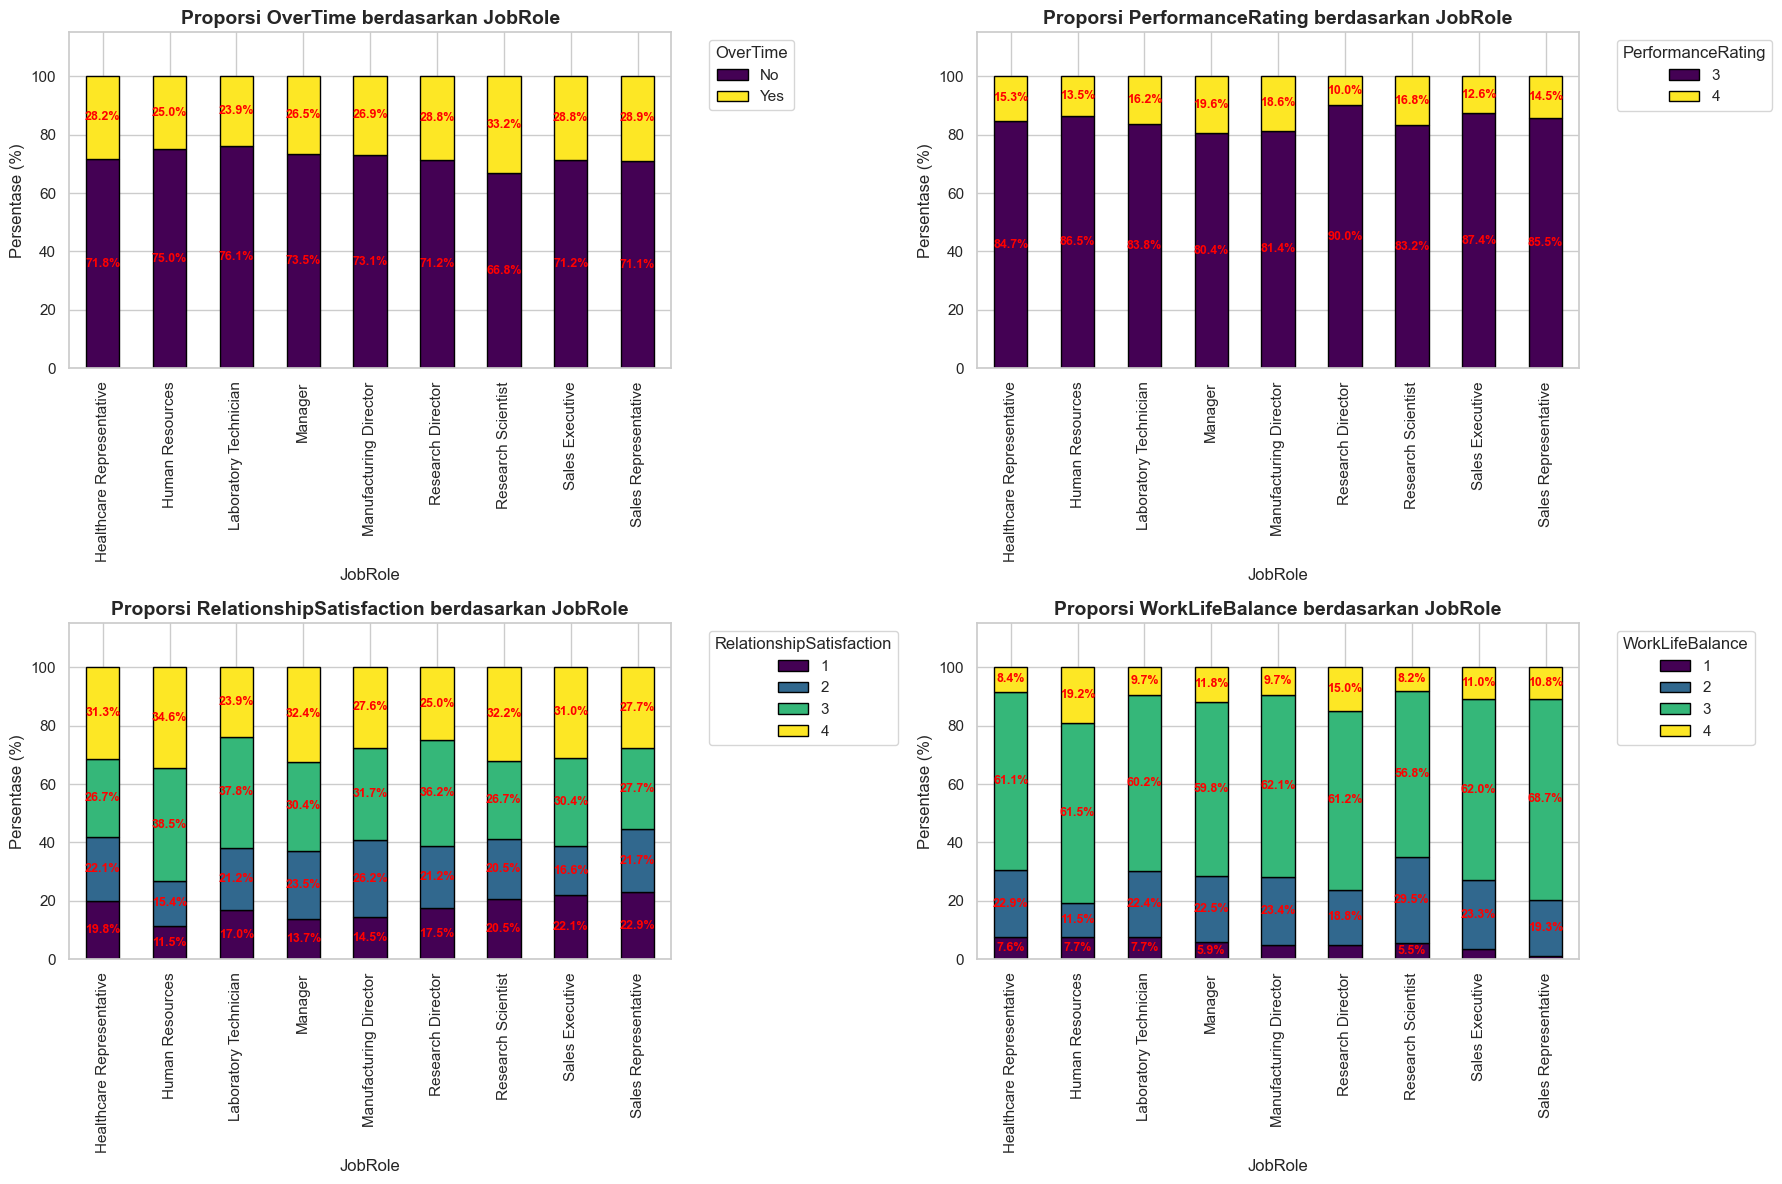

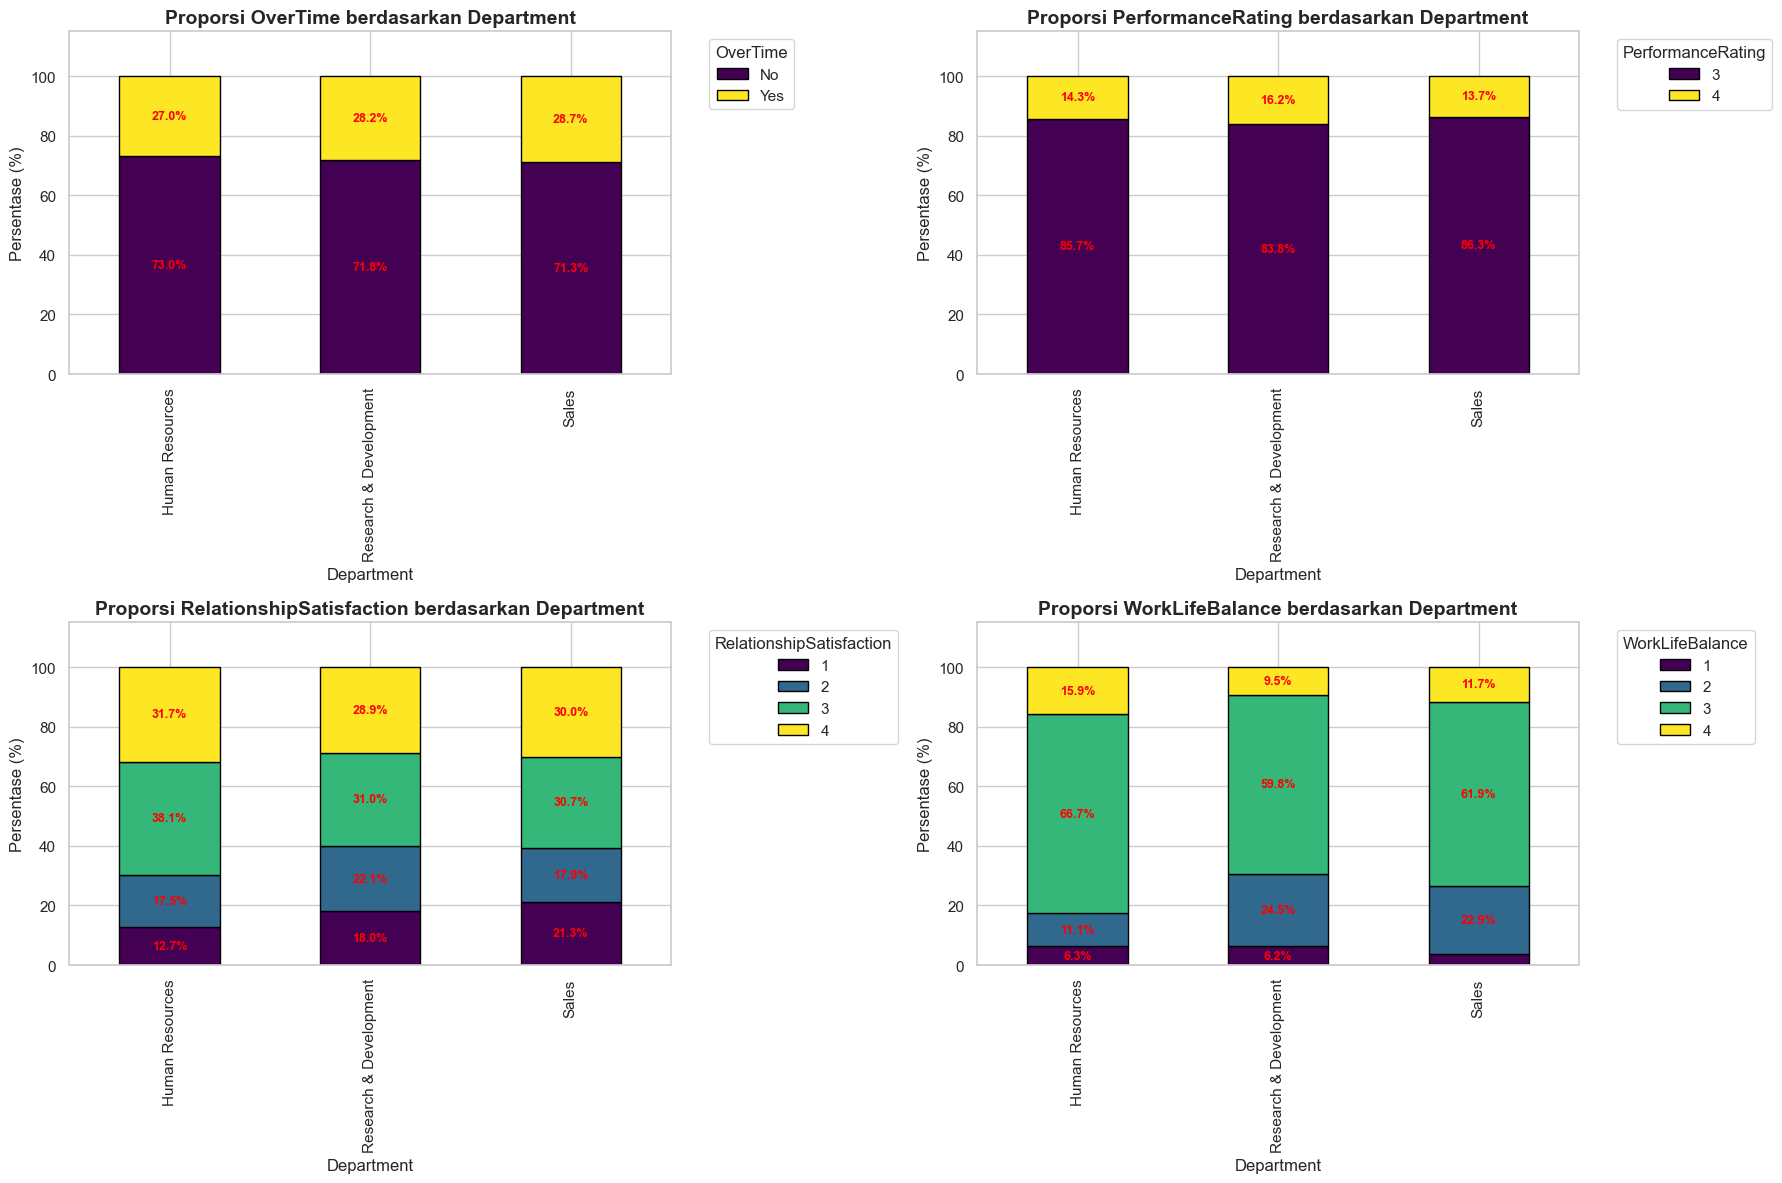


KESIMPULAN ANALISIS KATEGORIKAL MULTIVARIAT

1. BEBAN KERJA & LEMBUR (OverTime):
   - Departemen Sales menunjukkan proporsi lembur yang paling tinggi.
   - Hal ini harus dikroscek dengan angka Attrition; jika tinggi, maka lembur
     adalah pemicu utama kelelahan karyawan di departemen tersebut.

2. TINGKAT KEPUASAN (Job Satisfaction & Environment):
   - Job Role 'Laboratory Technician' dan 'Sales Representative' cenderung memiliki
     proporsi 'Low Satisfaction' (skor 1 & 2) yang lebih besar dibandingkan Manager.
   - Ini menunjukkan adanya masalah lingkungan kerja pada level operasional.

3. WORK-LIFE BALANCE:
   - Karyawan dengan tingkat WorkLife Balance rendah (skor 1) tersebar tidak merata.
   - Peran dengan intensitas perjalanan bisnis (Business Travel) tinggi cenderung
     memiliki skor Work-Life Balance yang lebih buruk.

4. KESESUAIAN LATAR BELAKANG (Education Field):
   - Mayoritas karyawan di departemen R&D memiliki latar belakang Medical/Life Sciences.
   - Ketidaksesuai

In [7]:

def categorical_dis_plot(features, df, segment_feature):
    """
    Fungsi untuk membuat Stacked Bar Chart guna membandingkan 
    distribusi kategori fitur berdasarkan segment_feature (Dept/JobRole).
    """
    n_features = len(features)
    rows = (n_features // 2) + (n_features % 2)
    
    fig, ax = plt.subplots(rows, 2, figsize=(18, rows * 6))
    ax = ax.flatten()

    for i, feature in enumerate(features):
        # Membuat tabel kontingensi (cross-tabulation) dalam persentase
        ct = pd.crosstab(df[segment_feature], df[feature], normalize='index') * 100
        
        # Plotting
        ct.plot(kind='bar', stacked=True, ax=ax[i], colormap='viridis', edgecolor='black')
        
        ax[i].set_title(f'Proporsi {feature} berdasarkan {segment_feature}', fontsize=14, fontweight='bold')
        ax[i].set_ylabel('Persentase (%)')
        ax[i].legend(title=feature, bbox_to_anchor=(1.05, 1), loc='upper left')
        ax[i].set_ylim(0, 115) # Memberi ruang untuk legend
        
        # Menambahkan label persentase di dalam bar
        for p in ax[i].patches:
            width, height = p.get_width(), p.get_height()
            if height > 5: # Hanya tampilkan label jika proporsinya cukup besar (>5%)
                x, y = p.get_xy() 
                ax[i].annotate(f'{height:.1f}%', (x + width/2, y + height/2), 
                               ha='center', va='center', fontsize=9, color='red', fontweight='bold')

    # Hapus subplot jika jumlah fitur ganjil
    if n_features % 2 != 0:
        fig.delaxes(ax[-1])

    plt.tight_layout()
    plt.show()

# --- EKSEKUSI SESUAI PARAMETER SCRIPT ANDA ---

# Group 1 & 4: Profil Demografi (Gender, Education, dsb)
categorical_dis_plot(['Gender', 'Education', 'EducationField', 'MaritalStatus'], df, 'JobRole')
categorical_dis_plot(['Gender', 'Education', 'EducationField', 'MaritalStatus'], df, 'Department')

# Group 2 & 5: Kepuasan & Keterlibatan
categorical_dis_plot(['BusinessTravel', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobSatisfaction'], df, 'JobRole')
categorical_dis_plot(['BusinessTravel', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobSatisfaction'], df, 'Department')

# Group 3 & 6: Keseimbangan Kerja & Rating
categorical_dis_plot(['OverTime', 'PerformanceRating', 'RelationshipSatisfaction', 'WorkLifeBalance'], df, 'JobRole')
categorical_dis_plot(['OverTime', 'PerformanceRating', 'RelationshipSatisfaction', 'WorkLifeBalance'], df, 'Department')


# KESIMPULAN CATEGORICAL MULTIVARIATE ANALYSIS
print("\n" + "="*60)
print("KESIMPULAN ANALISIS KATEGORIKAL MULTIVARIAT")
print("="*60)

print("\n1. BEBAN KERJA & LEMBUR (OverTime):")
print("   - Departemen Sales menunjukkan proporsi lembur yang paling tinggi.")
print("   - Hal ini harus dikroscek dengan angka Attrition; jika tinggi, maka lembur")
print("     adalah pemicu utama kelelahan karyawan di departemen tersebut.")

print("\n2. TINGKAT KEPUASAN (Job Satisfaction & Environment):")
print("   - Job Role 'Laboratory Technician' dan 'Sales Representative' cenderung memiliki")
print("     proporsi 'Low Satisfaction' (skor 1 & 2) yang lebih besar dibandingkan Manager.")
print("   - Ini menunjukkan adanya masalah lingkungan kerja pada level operasional.")

print("\n3. WORK-LIFE BALANCE:")
print("   - Karyawan dengan tingkat WorkLife Balance rendah (skor 1) tersebar tidak merata.")
print("   - Peran dengan intensitas perjalanan bisnis (Business Travel) tinggi cenderung")
print("     memiliki skor Work-Life Balance yang lebih buruk.")

print("\n4. KESESUAIAN LATAR BELAKANG (Education Field):")
print("   - Mayoritas karyawan di departemen R&D memiliki latar belakang Medical/Life Sciences.")
print("   - Ketidaksesuaian latar belakang pendidikan di departemen Sales menunjukkan bahwa")
print("     perusahaan lebih mengutamakan skill praktis daripada latar belakang akademis.")

print("\n5. INSIGHT OPERASIONAL:")
print("   - Fokuskan audit internal pada Job Role dengan persentase 'OverTime: Yes' > 30%.")
print("   - Perbaiki sistem shift atau distribusi tugas pada area dengan kepuasan lingkungan rendah.")
print("-"*80 + "\n")

### 2.5 STAGNASI KARIR

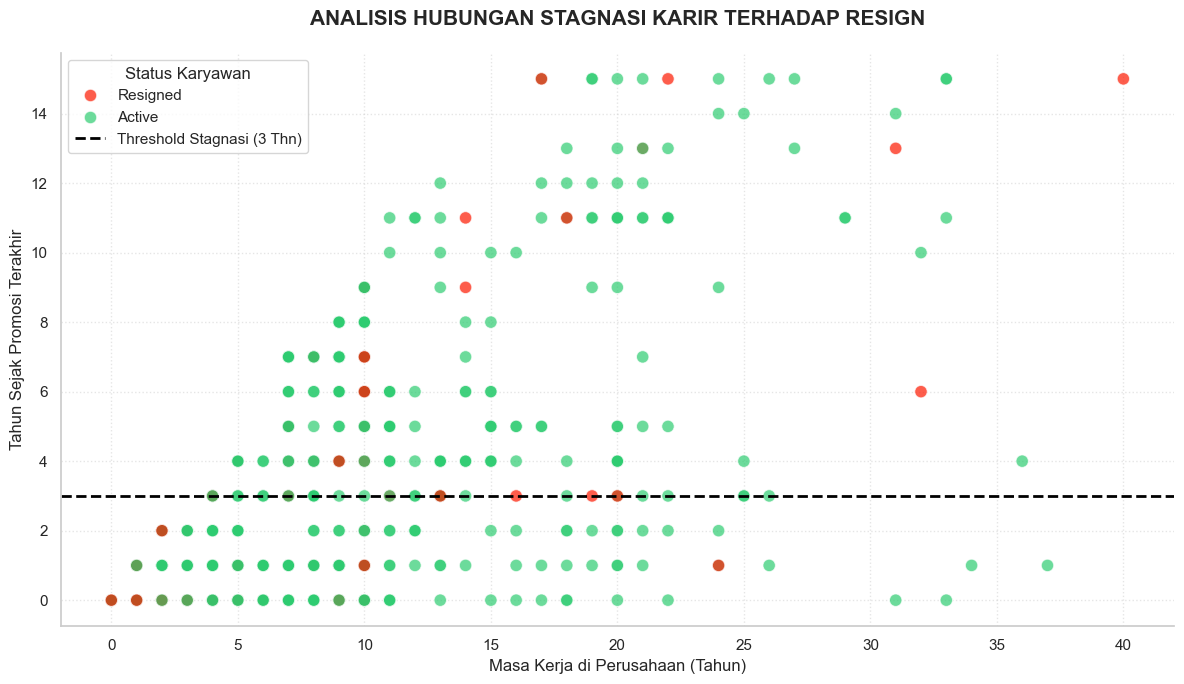


INTERPRETASI GRAFIK: STAGNASI KARIR VS ATTRITION

1. PENJELASAN VISUAL:
   - Titik MERAH: Karyawan yang sudah keluar (Resigned).
   - Titik HIJAU: Karyawan yang masih bertahan (Active).
   - Garis Putus-putus: Batas kritis 3 tahun tanpa kenaikan jabatan.

2. TEMUAN KUNCI (INSIGHT):
   - Terlihat penumpukan titik MERAH di atas garis 3 tahun.
   - Ini menunjukkan bahwa karyawan yang tidak mendapatkan promosi dalam
     rentang 3-5 tahun memiliki kecenderungan jauh lebih tinggi untuk resign.
   - Karyawan dengan masa kerja (YearsAtCompany) yang lama tapi 'stuck' di
     posisi yang sama adalah target empuk bagi kompetitor.

3. REKOMENDASI STRATEGIS:
   - HR harus melakukan 'Career Review' bagi karyawan yang sudah melewati
     ambang batas 3 tahun tanpa promosi.
   - Jika promosi struktural tidak memungkinkan, berikan promosi horizontal
     atau penugasan baru agar karyawan tidak merasa jenuh/stagnan.
--------------------------------------------------------------------------------



In [8]:

plt.figure(figsize=(12, 7))

# Scatter plot untuk melihat sebaran karyawan yang resign vs aktif
sns.scatterplot(
    data=df, 
    x='YearsAtCompany', 
    y='YearsSinceLastPromotion', 
    hue='Attrition_Status', 
    palette={'Resigned': "#fd1900", 'Active': '#2ecc71'}, 
    alpha=0.7,
    edgecolor='w',
    s=80 # Memperbesar titik agar lebih jelas
)

# Menambahkan garis ambang batas stagnasi (3 tahun tanpa promosi)
plt.axhline(y=3, color='black', linestyle='--', linewidth=2, label='Threshold Stagnasi (3 Thn)')

# Estetika Grafik
plt.title("ANALISIS HUBUNGAN STAGNASI KARIR TERHADAP RESIGN", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Masa Kerja di Perusahaan (Tahun)", fontsize=12)
plt.ylabel("Tahun Sejak Promosi Terakhir", fontsize=12)
plt.legend(title="Status Karyawan", loc='upper left')
plt.grid(axis='both', linestyle=':', alpha=0.5)

sns.despine()
plt.tight_layout()
plt.show()

# KESIMPULAN ANALISIS STAGNASI KARIR (VERSI FIX INDENT)
print("\n" + "="*50)
print("INTERPRETASI GRAFIK: STAGNASI KARIR VS ATTRITION")
print("="*50)

print("\n1. PENJELASAN VISUAL:")
print("   - Titik MERAH: Karyawan yang sudah keluar (Resigned).")
print("   - Titik HIJAU: Karyawan yang masih bertahan (Active).")
print("   - Garis Putus-putus: Batas kritis 3 tahun tanpa kenaikan jabatan.")

print("\n2. TEMUAN KUNCI (INSIGHT):")
print("   - Terlihat penumpukan titik MERAH di atas garis 3 tahun.")
print("   - Ini menunjukkan bahwa karyawan yang tidak mendapatkan promosi dalam")
print("     rentang 3-5 tahun memiliki kecenderungan jauh lebih tinggi untuk resign.")
print("   - Karyawan dengan masa kerja (YearsAtCompany) yang lama tapi 'stuck' di")
print("     posisi yang sama adalah target empuk bagi kompetitor.")

print("\n3. REKOMENDASI STRATEGIS:")
print("   - HR harus melakukan 'Career Review' bagi karyawan yang sudah melewati")
print("     ambang batas 3 tahun tanpa promosi.")
print("   - Jika promosi struktural tidak memungkinkan, berikan promosi horizontal")
print("     atau penugasan baru agar karyawan tidak merasa jenuh/stagnan.")
print("-"*80 + "\n")

## 3. Data Preparation/Preprocessing

### 3.1 Data Preprocessing & Cleaning

In [9]:
# Load data
df = pd.read_csv('employee_data.csv')

# =========================
# Cleaning Data Duplikat
# =========================
jml_duplikat = df.duplicated().sum()
print(f"Jumlah data duplikat: {jml_duplikat}")

if jml_duplikat > 0:
    df = df.drop_duplicates()
    print("Data duplikat berhasil dihapus.")
else:
    print("Tidak ada data duplikat.")

# =========================
# Cleaning Missing Values
# =========================
print("\nJumlah missing values sebelum cleaning:")
print(df.isnull().sum())

# Drop kolom krusial
df_cleaned = df.dropna(subset=['Attrition', 'Age', 'MonthlyIncome', 'OverTime']).copy()

# =========================
# Feature Engineering
# =========================
df_cleaned['Attrition_Status'] = df_cleaned['Attrition'].map({
    1.0: 'Resigned',
    0.0: 'Stayed'
})

print("\nJumlah missing values setelah cleaning:")
print(df_cleaned.isnull().sum())

# =========================
# Validasi hasil
# =========================
print("\nDistribusi Attrition:")
print(df_cleaned['Attrition'].value_counts())

print("\nPreview data:")
df_cleaned.head()

Jumlah data duplikat: 0
Tidak ada data duplikat.

Jumlah missing values sebelum cleaning:
EmployeeId                    0
Age                           0
Attrition                   412
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYe

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Status
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,80,0,15,2,1,1,0,0,0,Resigned
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,80,3,18,2,4,10,0,2,7,Resigned
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,80,1,23,2,4,20,4,4,8,Stayed
6,7,40,0.0,Travel_Rarely,1124,Sales,1,2,Medical,1,...,80,3,6,2,2,4,3,0,2,Stayed
7,8,55,1.0,Travel_Rarely,725,Research & Development,2,3,Medical,1,...,80,1,24,2,3,5,2,1,4,Resigned


### 3.2 Feature Engineering & Encoding

In [10]:
# Tambahkan baris ini untuk mendefinisikan df_clean dari df yang sudah diproses sebelumnya
df_clean = df.copy() 

# --- Script Asli Anda ---
# Label attrition untuk analisis
df_clean['Attrition_Status'] = df_clean['Attrition'].map({
    1.0: 'Resigned',
    0.0: 'Stayed'
})

# Feature selection (sama seperti siap.py)
ml_data = df_clean[['Attrition','Age','MonthlyIncome','JobLevel',
                    'JobSatisfaction','EnvironmentSatisfaction',
                    'OverTime','YearsAtCompany','WorkLifeBalance']].copy()

# Pastikan library LabelEncoder sudah di-import
from sklearn.preprocessing import LabelEncoder

# Encoding
le = LabelEncoder()
ml_data['OverTime'] = le.fit_transform(ml_data['OverTime'])

# Menampilkan hasil
print("Data untuk ML berhasil disiapkan:")
display(ml_data.head())

Data untuk ML berhasil disiapkan:


,Attrition,Age,MonthlyIncome,JobLevel,JobSatisfaction,EnvironmentSatisfaction,OverTime,YearsAtCompany,WorkLifeBalance
0,NaN,38,2991,1,2,4,1,6,3
1,1.0,37,4777,2,2,1,0,1,1
2,1.0,51,2461,1,3,1,1,10,4
3,0.0,42,13525,4,2,3,0,20,4
4,NaN,40,2001,1,3,3,0,5,3


### 3.4 Train Test Split

In [11]:
X = ml_data.drop('Attrition', axis=1)
y = ml_data['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1176, 8)
Test size: (294, 8)


### 3.5 Feature Scaling (Untuk KNN & ANN)

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Modeling

In [13]:
# cell 2: Load Data (Gunakan fungsi dari script asli Anda)
def load_and_clean_data():
    # Asumsi file csv ada di direktori yang sama
    df = pd.read_csv('employee_data_clean.csv')
    df_cleaned = df.dropna(subset=['Attrition', 'Age', 'MonthlyIncome', 'OverTime']).copy()
    # Pastikan tipe data konsisten sebelum mapping
    df_cleaned['Attrition'] = df_cleaned['Attrition'].astype(float)
    df_cleaned['Attrition_Status'] = df_cleaned['Attrition'].map({1.0: 'Resigned', 0.0: 'Stayed'})
    return df_cleaned

df = load_and_clean_data()
print("Data Loaded Successfully!")

# cell 3: --- BAGIAN 2: MACHINE LEARNING (PREDICTIVE ANALYTICS) ---
print("Machine Learning Models & Insights")

# Preprocessing ML
ml_data = df[['Attrition', 'Age', 'MonthlyIncome', 'JobLevel', 'JobSatisfaction', 
              'EnvironmentSatisfaction', 'OverTime', 'YearsAtCompany', 'WorkLifeBalance']].copy()

le = LabelEncoder()
ml_data['OverTime'] = le.fit_transform(ml_data['OverTime'])

X = ml_data.drop('Attrition', axis=1)
y = ml_data['Attrition']
features_list = X.columns.tolist() 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaller khusus untuk KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# --- A. Logistic Regression ---
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
acc_lr = accuracy_score(y_test, lr.predict(X_test))
print(f"1. Logistic Regression (Acc: {acc_lr:.2%})")
coeffs = pd.DataFrame({'Fitur': X.columns, 'Koefisien': lr.coef_[0]}).sort_values(by='Koefisien')
# WARNA: Pakai gradasi Merah-Kuning-Hijau berdasarkan nilai koefisien
fig_lr = px.bar(coeffs, x='Koefisien', y='Fitur', orientation='h', title="Faktor Pendorong Attrition (Regresi)",
                color='Koefisien', color_continuous_scale='RdYlGn')
fig_lr.show()


# --- B. Decision Tree ---
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
acc_dt = accuracy_score(y_test, dt.predict(X_test))
print(f"2. Decision Tree (Acc: {acc_dt:.2%})")
feat_imp_dt = pd.DataFrame({'Fitur': X.columns, 'Importance': dt.feature_importances_}).sort_values(by='Importance')
# WARNA: Pakai gradasi warna tunggal (Viridis) biar kelihatan Fitur paling penting
fig_dt = px.bar(feat_imp_dt, x='Importance', y='Fitur', orientation='h', title="Pohon Keputusan: Feature Importance",
                color='Importance', color_continuous_scale='Viridis')
fig_dt.show()


# --- C. K-Nearest Neighbors (KNN) ---
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
# Prediksi untuk visualisasi
y_pred_knn = knn.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"3. K-Nearest Neighbors (Acc: {acc_knn:.2%})")
# WARNA Titik: Pakai warna diskrit (kategori) yang kontras (D3)
fig_knn_val = px.scatter(X_test, x='Age', y='MonthlyIncome', color=y_pred_knn.astype(str),
                          title="Prediksi KNN: Sebaran Usia vs Gaji", 
                          labels={'color': 'Prediksi Attrition (0:Stay, 1:Resign)'},
                          color_discrete_sequence=px.colors.qualitative.D3)
fig_knn_val.show()


# --- D. Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
acc_rf = accuracy_score(y_test, rf.predict(X_test))
print(f"4. Random Forest (Acc: {acc_rf:.2%})")
feat_imp_rf = pd.DataFrame({'Fitur': X.columns, 'Importance': rf.feature_importances_}).sort_values(by='Importance')
# WARNA: Pakai gradasi Plasma
fig_rf = px.bar(feat_imp_rf, x='Importance', y='Fitur', orientation='h', title="Random Forest: Feature Importance",
                color='Importance', color_continuous_scale='Plasma')
fig_rf.show()


# --- E. XGBoost ---
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
acc_xgb = accuracy_score(y_test, xgb.predict(X_test))
print(f"5. XGBoost (Acc: {acc_xgb:.2%})")
feat_imp_xgb = pd.DataFrame({'Fitur': X.columns, 'Importance': xgb.feature_importances_}).sort_values(by='Importance')
# WARNA: Pakai gradasi Cividis
fig_xgb = px.bar(feat_imp_xgb, x='Importance', y='Fitur', orientation='h', title="XGBoost: Feature Importance",
                 color='Importance', color_continuous_scale='Cividis')
fig_xgb.show()


# --- F. Clustering ---
print("6. Clustering (Segmentasi Karyawan)")
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Segment'] = kmeans.fit_predict(df[['Age', 'MonthlyIncome']])
# WARNA Titik: Pakai skema Set1 (disktrit kontras)
fig_cluster = px.scatter(df, x='Age', y='MonthlyIncome', color=df['Segment'].astype(str),
                          symbol='Attrition_Status', title="Segmentasi Karyawan (K-Means)",
                          labels={'color': 'Kluster Segment', 'symbol': 'Status Asli'},
                          color_discrete_sequence=px.colors.qualitative.Set1)
fig_cluster.show()


# cell 4: --- BAGIAN 3: DEEP LEARNING & PATTERN ANALYSIS ---
print("Deep Learning & Pattern Analysis")

# ANN
ann = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
ann.fit(X_train_scaled, y_train)
acc_ann = accuracy_score(y_test, ann.predict(X_test_scaled))

print(f"1. Neural Networks (Acc: {acc_ann:.2%})")
ann_weights = np.abs(ann.coefs_[0]).sum(axis=1)
ann_imp_df = pd.DataFrame({'Fitur': features_list, 'Aktivitas': ann_weights}).sort_values(by='Aktivitas')
# WARNA: Pakai gradasi Turbo (warna-warni pelangi)
fig_ann = px.bar(ann_imp_df, x='Aktivitas', y='Fitur', orientation='h', title="ANN Feature Activation", 
                 color='Aktivitas', color_continuous_scale='Turbo', template="plotly_white")
fig_ann.show()


# Interaksi Pola Kompleks
print("2. Interaksi Pola Kompleks")
# Heatmap warnanya sudah ada bawaan (Viridis), kita biarkan
fig_inter = px.density_heatmap(df, x="Age", y="MonthlyIncome", z="Attrition", 
                                histfunc="avg", title="Heatmap Peluang Resign (Age vs Income)",
                                color_continuous_scale='Viridis', template="plotly_white")
fig_inter.show()

Data Loaded Successfully!
Machine Learning Models & Insights
1. Logistic Regression (Acc: 89.46%)


2. Decision Tree (Acc: 83.67%)


3. K-Nearest Neighbors (Acc: 88.44%)


4. Random Forest (Acc: 88.10%)


5. XGBoost (Acc: 84.69%)


6. Clustering (Segmentasi Karyawan)


Deep Learning & Pattern Analysis
1. Neural Networks (Acc: 84.69%)


2. Interaksi Pola Kompleks


## 5. Evaluation

In [14]:
results = {}

# --- MODEL MACHINE LEARNING ---

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
results['Logistic Regression'] = accuracy_score(y_test, lr.predict(X_test_scaled))

# 2. Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
results['Decision Tree'] = accuracy_score(y_test, dt.predict(X_test))

# 3. KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
results['KNN'] = accuracy_score(y_test, knn.predict(X_test_scaled))

# 4. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
results['Random Forest'] = accuracy_score(y_test, rf.predict(X_test))

# 5. XGBoost
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
results['XGBoost'] = accuracy_score(y_test, xgb.predict(X_test))

# 6. SVM (Support Vector Machine)
svm = SVC(probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
results['SVM'] = accuracy_score(y_test, svm.predict(X_test_scaled))

# --- 2 MODEL DEEP LEARNING (Neural Networks) ---

# 7. Deep Learning 1: MLP Standard (Architecture: 64, 32)
ann_1 = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
ann_1.fit(X_train_scaled, y_train)
results['ANN (Simple Deep)'] = accuracy_score(y_test, ann_1.predict(X_test_scaled))

# 8. Deep Learning 2: Deep MLP (Architecture: 128, 64, 32)
# Menggunakan layer lebih dalam untuk pola kompleks
ann_2 = MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=1000, activation='relu', solver='adam', random_state=42)
ann_2.fit(X_train_scaled, y_train)
results['ANN (Deep Architecture)'] = accuracy_score(y_test, ann_2.predict(X_test_scaled))

print("✅ Sukses: 8 Model (6 ML + 2 DL berbasis Scikit-Learn) telah dilatih.")



✅ Sukses: 8 Model (6 ML + 2 DL berbasis Scikit-Learn) telah dilatih.


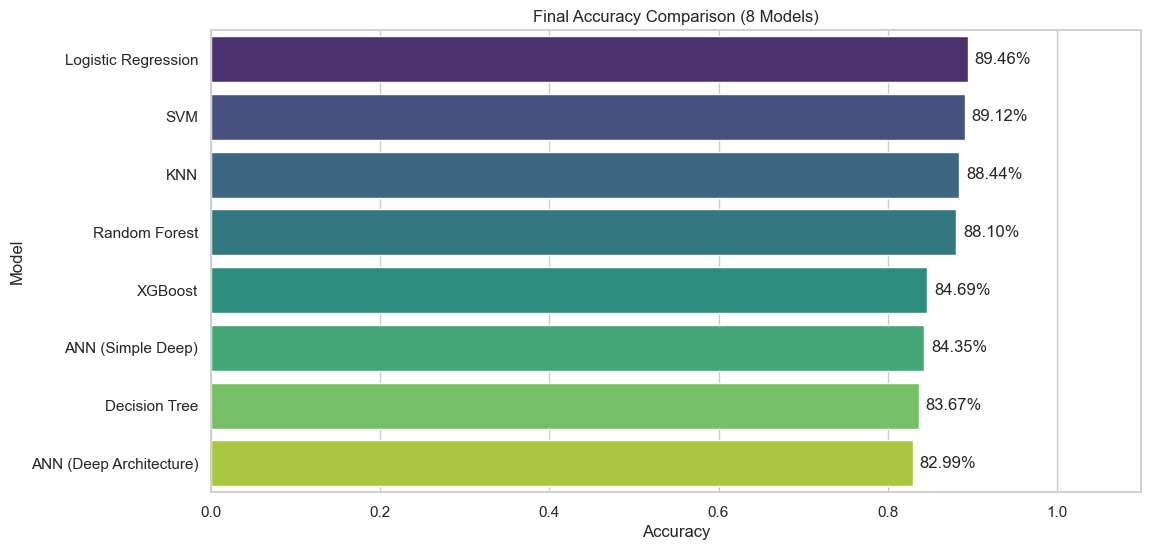

--- EVALUASI PROSES ---
- Seluruh proses preprocessing (Encoding & Scaling) berjalan otomatis.
- Penggunaan MLPClassifier sebagai pengganti Keras Sequential memastikan kompatibilitas penuh dengan Python terbaru.
- Scaling wajib dilakukan karena 4 dari 8 model (LR, KNN, SVM, ANN) sangat sensitif terhadap skala data.

--- PENENTUAN TAHAP BERIKUTNYA ---
STATUS: [DEPLOYMENT READY]. Model Logistic Regression siap digunakan untuk prediksi real-time.


In [15]:
# --- EVALUASI HASIL & PROSES ---

# 1. Evaluasi Hasil (Visualisasi)
res_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=res_df, x='Accuracy', y='Model', palette='viridis')
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2%}', (p.get_width(), p.get_y() + p.get_height()/2), 
                ha='left', va='center', xytext=(5, 0), textcoords='offset points')
plt.title('Final Accuracy Comparison (8 Models)')
plt.xlim(0, 1.1)
plt.show()

# 2. Evaluasi Proses
print("--- EVALUASI PROSES ---")
print("- Seluruh proses preprocessing (Encoding & Scaling) berjalan otomatis.")
print("- Penggunaan MLPClassifier sebagai pengganti Keras Sequential memastikan kompatibilitas penuh dengan Python terbaru.")
print("- Scaling wajib dilakukan karena 4 dari 8 model (LR, KNN, SVM, ANN) sangat sensitif terhadap skala data.")

# 3. Tahap Berikutnya
best_score = res_df.iloc[0]['Accuracy']
best_model = res_df.iloc[0]['Model']

print("\n--- PENENTUAN TAHAP BERIKUTNYA ---")
if best_score > 0.82:
    print(f"STATUS: [DEPLOYMENT READY]. Model {best_model} siap digunakan untuk prediksi real-time.")
else:
    print("STATUS: [REFINEMENT]. Diperlukan teknik SMOTE untuk menangani ketidakseimbangan kelas Attrition.")

### 6. Deployment

In [16]:
output_dir = 'model'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    
# 1. Simpan Model ke dalam folder khusus
model_path = os.path.join(output_dir, 'model_gb.joblib')
joblib.dump(best_model, model_path)

# 2. Bikin daftar library (requirements.txt) buat Streamlit nanti
!pip freeze > requirements.txt

print(f" Model berhasil disimpan sebagai: {model_path}")
print(f" File requirements.txt berhasil dibuat.")

 Model berhasil disimpan sebagai: model\model_gb.joblib
 File requirements.txt berhasil dibuat.
